In [1]:
!git clone https://github.com/mcordts/cityscapesScripts.git

Cloning into 'cityscapesScripts'...
remote: Enumerating objects: 674, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 674 (delta 195), reused 184 (delta 163), pack-reused 427 (from 1)
Receiving objects: 100% (674/674), 837.07 KiB | 16.10 MiB/s, done.
Resolving deltas: 100% (381/381), done.


In [2]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
# import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
import torchvision.transforms.v2 as T

from cityscapesScripts.cityscapesscripts.helpers.labels import id2label, trainId2label, labels, name2label

# Helper

In [43]:
from omegaconf import OmegaConf

def load_config(filepath):
    with open(filepath, 'r') as f:
        return OmegaConf.load(f)
    

path_cfg = load_config("/kaggle/input/segment-city/path_config.yaml")
train_cfg = load_config("/kaggle/input/segment-city/train_config.yaml")
model_cfg = load_config("/kaggle/input/segment-city/model_config.yaml")
path_cfg.dataset_path = "/kaggle/input/cityscapes/Cityscapes"
config = OmegaConf.merge(path_cfg, train_cfg, model_cfg)

config.device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
def convert_instance_to_semantic(instance_masks, instance_labels):
    """
    Converts an instance mask of shape [N, H, W] to a semantic mask of shape [H, W].
    
    This is done by "painting" the class ID from instance_labels onto the
    corresponding binary mask from instance_masks.
    """
    if instance_masks.ndim != 3 or instance_labels.ndim != 1:
        raise ValueError(f"Expected shapes [N, H, W] and [N], but got "
                         f"{instance_masks.shape} and {instance_labels.shape}")
    
    # Reshape labels to [N, 1, 1] to allow broadcasting
    reshaped_labels = instance_labels.view(-1, 1, 1)
    
    # Multiply masks by their labels and take the max to handle overlaps
    # The result is a single [H, W] tensor where each pixel has the class ID
    semantic_mask = torch.max(instance_masks.float() * reshaped_labels, dim=0)[0]
    
    return semantic_mask.long()

def colorize_mask(mask, color_dict):
    """Converts a HxW segmentation mask of class indices to a 3xHxW RGB image."""
    # Ensure mask is on CPU and is a numpy array
    mask_np = mask.cpu().numpy()
    rgb_mask = np.zeros((mask_np.shape[0], mask_np.shape[1], 3), dtype=np.uint8)
    
    present_classes = np.unique(mask_np)
    for class_id in present_classes:
        if class_id in color_dict:
            indices = (mask_np == class_id)
            # Assign the corresponding color
            rgb_mask[indices] = color_dict[class_id]
            
    return torch.from_numpy(rgb_mask).permute(2, 0, 1)

# Model

In [5]:
import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, X):
        return self.double_conv(X)

class DownLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, X):
        return self.maxpool_conv(X)

class UpLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, X, C):
        X = self.up(X)
        diffY = C.size()[2] - X.size()[2]
        diffX = C.size()[3] - X.size()[3]

        X = nn.functional.pad(X, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        X = torch.cat([C, X], dim = 1)
        return self.conv(X)
    
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.conv(x)

class UNET(nn.Module):
    def __init__(self, n_channels, n_classes) -> None:
        super(UNET, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.inp = DoubleConv(n_channels, 64)
        self.down1 = DownLayer(64, 128)
        self.down2 = DownLayer(128, 256)
        self.down3 = DownLayer(256, 512)
        self.down4 = DownLayer(512, 1024)

        self.up1 = UpLayer(1024, 512)
        self.up2 = UpLayer(512, 256)
        self.up3 = UpLayer(256, 128)
        self.up4 = UpLayer(128, 64)
        self.out = OutConv(64, n_classes)

    def contracting_path(self, X):
        out1 = self.down1(X) # 128 x 280 x 280
        out2 = self.down2(out1) # 256 x 136 x 136
        out3 = self.down3(out2) # 512 x 64 x 64
        out4 = self.down4(out3) # 1024 x 28 x 28
        return out1, out2, out3, out4
    
    def expansive_path(self, c4, c3, c2, c1, c0):
        out = self.up1(c4, c3) # 512 x 52 x 52
        out = self.up2(out, c2) # 256 x 100 x 100
        out = self.up3(out, c1) # 128 x 196 x 196
        out = self.up4(out, c0) # 64 x 388 x 388
        return out
    
    def forward(self, X):
        c0 = self.inp(X) # 64 x 568 x 568
        c1, c2, c3, c4 = self.contracting_path(c0)
        e = self.expansive_path(c4, c3, c2, c1, c0)
        logits = self.out(e) # 2 x 388 x 388
        return logits

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights

def build_MaskRCNN(num_classes):
    weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    maskrcnn = maskrcnn_resnet50_fpn_v2(weights)
    
    in_features_box = maskrcnn.roi_heads.box_predictor.cls_score.in_features
    in_features_mask = maskrcnn.roi_heads.mask_predictor.conv5_mask.in_channels
    
    dim_reduced = maskrcnn.roi_heads.mask_predictor.conv5_mask.out_channels
    
    maskrcnn.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_features_box, num_classes=num_classes)
    maskrcnn.roi_heads.mask_predictor = MaskRCNNPredictor(in_channels=in_features_mask, dim_reduced=dim_reduced, num_classes=num_classes)
    return maskrcnn

In [6]:
def build_model(model_config, num_channels=3, num_classes=20):
    if model_config.model_name.lower() == "unet":
        return UNET(num_channels, num_classes)
    elif model_config.model_name.lower() == "maskrcnn":
        return build_MaskRCNN(num_classes)
    else:
        print(f"{model_config.model_name} is currently not supported")

# Dataset

In [7]:
class CityscapesDataset(Dataset):
    def __init__(self, config, id_to_trainId_map, ignore_index=255, transform=None, split='train'):
        super().__init__()
        self.images = [] # path to leftImg8bit
        self.label_images = [] # path to labels images
        self.instances = [] # path to instance images

        self.ignore_index = ignore_index
        self.id_to_trainId_map = id_to_trainId_map
        self.config = config
        self._transform = transform
        self.task = config.task

        self.class_names = [label.category for label in labels]

        left8bit_path = os.path.join(self.config.dataset_path, "leftImg8bit", split)
        for city in os.listdir(left8bit_path):
            city_images = list(os.listdir(os.path.join(left8bit_path, city)))
            city_images = [os.path.join(left8bit_path, city, image) for image in city_images]
            self.images.extend(city_images)
            
        for city in os.listdir(os.path.join(self.config.dataset_path, self.config.type, split)):
            city_dir = os.path.join(self.config.dataset_path, self.config.type, split, city)
            for file in os.listdir(city_dir):
                if file.endswith("labelIds.png"):
                    self.label_images.append(os.path.join(city_dir, file))
                elif file.endswith("instanceIds.png"):
                    self.instances.append(os.path.join(city_dir, file))

        self.images = sorted(self.images)
        self.label_images = sorted(self.label_images)
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load the raw RGB image
        img = read_image(str(self.images[idx]))

        # Dispatch to the correct handler based on the task
        if self.task == "semantic":
            img, target = self._get_semantic_item(idx, img)
        elif self.task == "instance":
            # img, target = self._get_instance_item(idx, img)
            print("currently not supported")
        
        # Apply transformations (e.g., augmentations, resizing)
        if self._transform:
            img, target = self._transform(img, target)
            
        return img, target

    def _get_semantic_item(self, idx, img):
        """Prepares a target for a semantic segmentation task."""
        mask = read_image(str(self.label_images[idx])).long() # Shape: [1, H, W]

        converted_mask = torch.full_like(mask, self.ignore_index) 
        converted_mask[mask == -1] = self.ignore_index
        valid_pixels = (mask >= 0) & (mask <= 33)
        converted_mask[valid_pixels] = self.id_to_trainId_map[mask[valid_pixels]]
        # print(converted_mask.shape)

        obj_ids = torch.unique(converted_mask).to(dtype=torch.uint8)
        # print(obj_ids)
        converted_mask = (converted_mask == obj_ids[:, None, None]).to(dtype=torch.long)
        # print(converted_mask.shape)
        boxes = masks_to_boxes(converted_mask)
        labels = obj_ids[:, None].to(dtype=torch.int64)
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        
        # The target for semantic segmentation is just the mask
        widths = boxes[:, 2] - boxes[:, 0]
        heights = boxes[:, 3] - boxes[:, 1]
        valid_boxes_mask = (widths > 0) & (heights > 0)
        # print(valid_boxes_mask.shape)
        
        boxes = boxes[valid_boxes_mask]
        converted_mask = converted_mask[valid_boxes_mask]
        labels = labels[valid_boxes_mask]
        iscrowd = iscrowd[valid_boxes_mask] 

        # if 255 in labels:
        #     boxes = boxes[:-1, :]
        #     converted_mask = converted_mask[:-1, :, :]
        #     labels = labels[:-1]
        #     iscrowd = iscrowd[:-1] 
            
        target = {}
        target["masks"] = tv_tensors.Mask(converted_mask) # Shape: [H, W]
        target["labels"] = labels.squeeze(1) 
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=T.functional.get_size(img))
        target["iscrowd"] = iscrowd
        target["area"] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        return tv_tensors.Image(img), target

In [8]:
def collate_fn(batch):
    """
    Since the number of objects varies per image, we collate the images and targets
    into lists. The model expects a list of images and a list of targets dictionaries.
    """
    # batch is a list of tuples: [(img1, target1), (img2, target2), ...]
    images = [item[0] for item in batch] # This will be a list of image tensors/tv_tensors.Image
    targets = [item[1] for item in batch] # This will be a list of target dictionaries
    return images, targets

def get_dataloader(dataset, config, is_train=True):
    dataloader = DataLoader(dataset, batch_size=(config.per_gpu_train_batch_size if is_train else config.per_gpu_eval_batch_size), num_workers=config.num_workers, shuffle=is_train, collate_fn = collate_fn)
    return dataloader

# 20 Classes MaskRCNN


In [9]:
class_names_20c = {} # MaskRCNN only
class_id_to_name_20c = {}
class_id_to_color_20c = {}
colors_map = {}
id_to_trainId_map_20c = torch.zeros((34,), dtype=torch.long)

In [10]:
for label in labels:
    if 0 <= label.id and label.id <= 33: # Handle all valid IDs
        id_to_trainId_map_20c[label.id] = label.trainId + 1
        class_names_20c[label.id] = label.name
        if label.trainId == 255:
            id_to_trainId_map_20c[label.id] = 0

for l in labels:
    if l[2] != 255 and l[2] != -1:
        class_id_to_name_20c[l[2]+1] = l[0]
        class_id_to_color_20c[l[2]+1] = l[-1]
    else:
        class_id_to_name_20c[0] = l[0]
        class_id_to_color_20c[0] = l[-1]
    colors_map[l[2]] = l[-1]

captions_20c = [v for v in class_id_to_name_20c.values()]
captions_20c.insert(0, "unlabel")
colors_map[255] = (0, 0, 0)
colors_map[-1] = (0, 0, 0)
colors_map

{255: (0, 0, 0),
 0: (128, 64, 128),
 1: (244, 35, 232),
 2: (70, 70, 70),
 3: (102, 102, 156),
 4: (190, 153, 153),
 5: (153, 153, 153),
 6: (250, 170, 30),
 7: (220, 220, 0),
 8: (107, 142, 35),
 9: (152, 251, 152),
 10: (70, 130, 180),
 11: (220, 20, 60),
 12: (255, 0, 0),
 13: (0, 0, 142),
 14: (0, 0, 70),
 15: (0, 60, 100),
 16: (0, 80, 100),
 17: (0, 0, 230),
 18: (119, 11, 32),
 -1: (0, 0, 0)}

# 19 Classes

In [11]:
class_names_19c = {} # MaskRCNN only
class_id_to_name_19c = {}
class_id_to_color_19c = {}
id_to_trainId_map_19c = torch.zeros((34,), dtype=torch.long)
class_trainId_to_color_19c = {} # UNet only

In [12]:
for label in labels:
    if 0 <= label.id <= 33:
        id_to_trainId_map_19c[label.id] = label.trainId
        class_names_19c[label.id] = label.name


for l in labels:
    class_id_to_name_19c[l[2]] = l[0]
    class_id_to_color_19c[l[2]] = l[-1]

# 9 Classes MaskRCNN

In [13]:
class_names_9c = {} # MaskRCNN only
class_id_to_name_9c = {}
class_id_to_color_9c = {}
id_to_trainId_map_9c = torch.zeros((34,), dtype=torch.long)
class_trainId_to_color_9c = {}

In [14]:
valid_label_9c = [24, 25, 26, 27, 28, 31, 32, 33]
valid_label_to_trainLabel_9c = {
    24: 1, 
    25: 2, 
    26: 3, 
    27: 4, 
    28: 5, 
    31: 6, 
    32: 7, 
    33: 8
}
trainLabel_to_valid_label_9c = {
    1: 24, 
    2: 25, 
    3: 26, 
    4: 27, 
    5: 28, 
    6: 31, 
    7: 32, 
    8: 33
}
for label in labels:
    if label.id in valid_label_9c:
        id_to_trainId_map_9c[label.id] = valid_label_to_trainLabel_9c[label.id] # 11..18 ~ 1..8 (0 for background) 
        class_names_9c[valid_label_to_trainLabel_9c[label.id]] = label.name

for l in labels:
    if l[2] != 255: # trainId != 255
        class_id_to_name_9c[l[2]] = l[0]
        class_id_to_color_9c[l[2]] = l[-1]
        if 11 <= l[2] and l[2] <= 18:
            class_trainId_to_color_9c[l[2]-10] = l[-1]
    colors_map[l[2]] = l[-1]

class_trainId_to_color_9c[0] = (0, 0, 0)
captions_9c = ["unlabel"]
for i in range(11, 19):
    captions_9c.append(class_id_to_name_9c[i])

colors_map[255] = (0, 0, 0)
colors_map[-1] = (0, 0, 0)

# 8 Classes

In [15]:
class_names_8c = {}
class_id_to_name_8c = {}
class_id_to_color_8c = {}
id_to_trainId_map_8c = torch.zeros((34,), dtype=torch.long)
class_trainId_to_color_8c = {} # UNet only

In [16]:
valid_label_8c = [24, 25, 26, 27, 28, 31, 32, 33]
valid_label_to_trainLabel_8c = {
    24: 0, 
    25: 1, 
    26: 2, 
    27: 3, 
    28: 4, 
    31: 5, 
    32: 6, 
    33: 7
}
trainLabel_to_valid_label_8c = {
    0: 24, 
    1: 25, 
    2: 26, 
    3: 27, 
    4: 28, 
    5: 31, 
    6: 32, 
    7: 33
}
for label in labels:
    if label.id in valid_label_8c:
        id_to_trainId_map_8c[label.id] = valid_label_to_trainLabel_8c[label.id] # 11..18 ~ 1..8 (0 for background) 
        class_names_8c[valid_label_to_trainLabel_8c[label.id]] = label.name

for l in labels:
    class_id_to_name_8c[l[2]] = l[0]
    class_id_to_color_8c[l[2]] = l[-1]
    if 11 <= l[2] and l[2] <= 18:
        class_trainId_to_color_8c[l[2]-11] = l[-1] ####################### Essential for 8 class

# Transform

In [17]:
train_augmentation_maskrcnn = T.Compose([
    T.Resize((512,1024)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    # T.RandomSolarize(threshold=19.0),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0)),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) 
val_augmentation_maskrcnn = T.Compose([
    T.Resize((512,1024)),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_augmentation_unet = T.Compose([
    T.Resize((512,1024)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    # T.RandomSolarize(threshold=19.0),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0)),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) 
val_augmentation_unet = T.Compose([
    T.Resize((512,1024)),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Metrics

## Dice

In [18]:
import torch
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self,  epsilon: float = 1e-6):
        super().__init__()
        self.epsilon = epsilon
        
    @staticmethod
    def _calculate_dice_coeff(input_mask: Tensor, target: Tensor, reduce_batch_first: bool = False, epsilon: float = 1e-6):
        """
        Calculates the Dice coefficient for binary masks.
        Args:
            input_mask (Tensor): Predicted mask, expected to be probabilities (float).
            target (Tensor): Ground truth mask, expected to be binary (0 or 1, float).
            reduce_batch_first (bool): If True, computes a single Dice score over the entire batch
                                       (B, H, W) -> scalar. If False, computes Dice per item (B, H, W) -> B scores.
            epsilon (float): Small constant to avoid division by zero.
        Returns:
            Tensor: Dice coefficient.
        """
        # print(input_mask.size(), target.size())
        assert input_mask.size() == target.size(), f"Input and target must have the same size. Got {input_mask.size()} and {target.size()}"
        assert input_mask.dim() >= 2, "Input mask must have at least 2 dimensions (H, W)"
        assert input_mask.dim() == 3 or not reduce_batch_first, \
            "If reduce_batch_first is True, input_mask must be 3-dimensional (B, H, W) after potential flattening."
    
        # Determine dimensions to sum over
        if reduce_batch_first: # Sum over B, H, W
            sum_dim = (-1, -2, -3) # Assumes B, H, W for input_mask.dim() == 3, or C, H, W after flatten(0,1) from B, C, H, W
        else: # Sum over H, W (per item in batch/channel)
            sum_dim = (-1, -2)
    
        inter = 2 * (input_mask * target).sum(dim=sum_dim)  # 2 * |A giao B|
        sets_sum = input_mask.sum(dim=sum_dim) + target.sum(dim=sum_dim)  # |A| + |B|
        
        # Handle cases where sets_sum is 0 to avoid NaNs, set dice to 1 if both are empty (inter=0, sets_sum=0)
        # The original implementation had a condition where if sets_sum == 0, inter was used.
        # This leads to dice = (0 + eps) / (0 + eps) = 1 if both input and target are entirely zero.
        # Let's keep that behavior.
        sets_sum = torch.where(sets_sum == 0, inter, sets_sum)
        #print("sets_sum = ", sets_sum)
        dice = (inter + epsilon) / (sets_sum + epsilon)  # (2 * |A giao B| + eps) / (|A| + |B| + eps)
        return dice.mean()
    
    def _multiclass_dice_coeff(self, input_mask: Tensor, target: Tensor, reduce_batch_first: bool = False):
        """
        Calculates the average Dice coefficient across all classes for multi-class segmentation.
        Flattens (B, C, H, W) to (B*C, H, W) and calls dice_coeff.
        Args:
            input_mask (Tensor): Predicted masks, shape (B, C, H, W), probabilities (float).
            target (Tensor): Ground truth masks, shape (B, C, H, W), one-hot encoded (float).
            reduce_batch_first (bool): If True, computes a single Dice score over the entire (B*C) flattened batch.
                                       If False, computes Dice per (B*C) item.
            epsilon (float): Small constant to avoid division by zero.
        Returns:
            Tensor: Average Dice coefficient.
        """
        # Flatten N and C dimensions to treat each class in each batch as a separate binary mask
        # Shape changes from (N, C, H, W) to (N*C, H, W)
        return self._calculate_dice_coeff(
            input_mask.flatten(0, 1), 
            target.flatten(0, 1), 
            reduce_batch_first, 
            self.epsilon
        )

    def _binary_dice_coeff(self, input_mask: Tensor, target: Tensor, reduce_batch_first: bool) -> Tensor:
        return self._calculate_dice_coeff(
            input_mask, 
            target, 
            reduce_batch_first, 
            self.epsilon
        )
    
    def forward(self, input_mask: Tensor, target: Tensor, multiclass: bool = False):
        """
        Calculates the Dice loss (objective to minimize) between 0 and 1.
        Args:
            input_mask (Tensor): Predicted mask (logits or probabilities) (B, C, H, W).
            target (Tensor): Ground truth mask (binary or one-hot encoded)  (B, C, H, W).
            multiclass (bool): If True, uses multiclass_dice_coeff; otherwise, uses dice_coeff.
        Returns:
            Tensor: Dice loss (1 - Dice_coefficient).
        """
        # Note: If input_mask are logits, they should be passed through softmax/sigmoid before
        # being used with dice_coeff/multiclass_dice_coeff for optimal results,
        # as these functions expect probabilities or binary masks.
        fn = self._multiclass_dice_coeff if multiclass else self._binary_dice_coeff
        # Assuming input_mask might be logits, convert to probabilities
        if multiclass:
            input_probs = F.softmax(input_mask, dim=1)
            if input_probs.shape[1] > target.shape[1]:
                input_probs = input_probs[:, 1:, ...]
        elif input_mask.dim() == target.dim(): # Binary case, e.g., (N, H, W)
            input_probs = torch.sigmoid(input_mask)
        else:
            input_probs = input_mask
    
        return 1 - fn(input_probs, target, reduce_batch_first=True)

## mIoU

In [19]:
from torchmetrics.segmentation import MeanIoU
from torchmetrics.detection import MeanAveragePrecision

In [20]:
class CustomMeanIoU:
    def __init__(self, num_classes: int, ignore_index: int = None, device: torch.device = None):
        """
        Custom MeanIoU metric that explicitly handles an ignore_index.

        Args:
            num_classes (int): The number of valid classes (excluding the ignore_index).
            ignore_index (int, optional): The class label to ignore in calculations. Defaults to None.
            device (torch.device, optional): The device to store internal tensors on. Defaults to None (CPU).
        """
        if num_classes <= 0:
            raise ValueError("num_classes must be a positive integer.")
        
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.device = device if device is not None else torch.device("cpu")

        self.intersections = torch.zeros(num_classes, dtype=torch.long, device=self.device)
        self.unions = torch.zeros(num_classes, dtype=torch.long, device=self.device)
        
        self._num_updates = 0

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        """
        Update the metric state with new predictions (logits) and targets (one-hot masks).

        Args:
            preds (torch.Tensor): Predicted mask logits (float tensor, shape [B, C, H, W]).
            target (torch.Tensor): Ground truth semantic masks (long/float tensor, shape [B, C, H, W] - assumed one-hot or similar).
                                   Values should represent class membership.
                                   If target is already class IDs [B, H, W], please adjust this function.
        """
        # --- 1. Convert logits to predicted class IDs [B, H, W] ---
        if preds.dim() != 4:
            raise ValueError(f"Preds must be [B, C, H, W] where C is num_classes. Got {preds.shape}")
        predicted_classes = torch.argmax(preds, dim=1).to(torch.long)

        # --- 2. Convert target from multi-channel (e.g., one-hot) to class IDs [B, H, W] ---
        if target.dim() == 4:
            if target.shape[1] != 1:
                target_classes = torch.argmax(target, dim=1).clone().to(torch.long)
            else:
                target_classes = target.squeeze(1).clone().to(torch.long) # Added .clone() for safety
        elif target.dim() == 3:
            target_classes = target.clone().to(torch.long)
        else:
            raise ValueError(
                f"Unsupported target shape or format. Expected [B, C, H, W] (one-hot), "
                f"[B, 1, H, W], or [B, H, W] (class IDs). Got {target.shape}"
            )

        if predicted_classes.shape != target_classes.shape:
            raise ValueError(
                f"Predicted and target class maps must have the same spatial shape. "
                f"Got predicted: {predicted_classes.shape} and target: {target_classes.shape}"
            )
        
        predicted_classes = predicted_classes.to(self.device)
        target_classes = target_classes.to(self.device)

        valid_mask = torch.ones_like(target_classes, dtype=torch.bool, device=self.device)
        if self.ignore_index is not None:
            valid_mask = (target_classes != self.ignore_index)

        preds_valid = predicted_classes[valid_mask]
        target_valid = target_classes[valid_mask]
        
        for c in range(self.num_classes):
            target_c = (target_valid == c)
            preds_c = (preds_valid == c)

            intersection = (preds_c & target_c).sum()
            union = (preds_c | target_c).sum()

            self.intersections[c] += intersection
            self.unions[c] += union
            
        self._num_updates += preds.shape[0]

    def compute(self) -> float:
        """
        Compute the Mean IoU based on accumulated intersections and unions.

        Returns:
            float: The Mean IoU value. Returns 0.0 if no valid pixels were processed.
        """
        ious = torch.zeros(self.num_classes, dtype=torch.float, device=self.device)

        for c in range(self.num_classes):
            if self.unions[c] > 0:
                ious[c] = self.intersections[c].float() / self.unions[c].float()
            else:
                # If a class had no ground truth or predictions in valid regions, its IoU is NaN
                # We will ignore these NaNs when computing the mean.
                ious[c] = torch.nan 

        # Filter out NaN values (classes with no occurrences) for mean calculation
        valid_ious = ious[~torch.isnan(ious)]
        # print(ious)
        if len(valid_ious) == 0:
            return 0.0
            
        mean_iou = torch.mean(valid_ious)
        return mean_iou.item()

    def reset(self):
        """
        Reset the metric state.
        """
        self.intersections = torch.zeros(self.num_classes, dtype=torch.long, device=self.device)
        self.unions = torch.zeros(self.num_classes, dtype=torch.long, device=self.device)
        self._num_updates = 0

In [21]:
mIoU_metric_U19c = CustomMeanIoU(
    num_classes=19,
    ignore_index=255
)
mIoU_metric_U8c = CustomMeanIoU(
    num_classes=8,
    ignore_index=255
)
mIoU_metric_M20c = MeanIoU(num_classes=20, include_background=False)
mIoU_metric_M9c = MeanIoU(num_classes=9, include_background=False)

## mAP

In [22]:
# https://github.com/matterport/Mask_RCNN

def compute_overlaps_masks(masks1, masks2):
    """Computes IoU overlaps between two sets of masks.
    masks1, masks2: [Height, Width, instances]
    """
    
    # If either set of masks is empty return empty result
    if masks1.shape[-1] == 0 or masks2.shape[-1] == 0:
        return np.zeros((masks1.shape[-1], masks2.shape[-1]))
        
    # flatten masks and compute their areas
    masks1 = np.reshape(masks1 > .5, (-1, masks1.shape[-1])).astype(np.float32)
    masks2 = np.reshape(masks2 > .5, (-1, masks2.shape[-1])).astype(np.float32)
    area1 = np.sum(masks1, axis=0)
    area2 = np.sum(masks2, axis=0)
    # intersections and union
    intersections = np.dot(masks1.T, masks2)
    union = area1[:, None] + area2[None, :] - intersections
    overlaps = intersections / union
    
    return overlaps

def trim_zeros(x):
    """It's common to have tensors larger than the available data and
    pad with zeros. This function removes rows that are all zeros.

    x: [rows, columns].
    """
    assert len(x.shape) == 2
    return x[~np.all(x == 0, axis=1)]
    
def compute_matches(gt_boxes, gt_class_ids, gt_masks,
                    pred_boxes, pred_class_ids, pred_scores, pred_masks,
                    iou_threshold=0.5, score_threshold=0.1): # low score threshold
    """Finds matches between prediction and ground truth instances.

    Returns:
        gt_match: 1-D array. For each GT box it has the index of the matched
                  predicted box.
        pred_match: 1-D array. For each predicted box, it has the index of
                    the matched ground truth box.
        overlaps: [pred_boxes, gt_boxes] IoU overlaps.
    """
    # Trim zero padding
    # TODO: cleaner to do zero unpadding upstream
    # gt_boxes = trim_zeros(gt_boxes)
    gt_masks = gt_masks[..., :gt_boxes.shape[0]]
    # pred_boxes = trim_zeros(pred_boxes)
    pred_scores = pred_scores[:pred_boxes.shape[0]]
    # Sort predictions by score from high to low
    indices = np.argsort(pred_scores)[::-1].copy()
    pred_boxes = pred_boxes[indices]
    pred_class_ids = pred_class_ids[indices]
    pred_scores = pred_scores[indices]
    pred_masks = pred_masks[..., indices]

    # Compute IoU overlaps [pred_masks, gt_masks]
    overlaps = compute_overlaps_masks(pred_masks, gt_masks)
    # print(overlaps.shape)
    # plt.figure(figsize=(15, 18))
    # plt.imshow(overlaps, interpolation='nearest', cmap=plt.cm.Blues)
    # plt.colorbar()
    
    # tick_marks_gt = np.arange(len(gt_class_ids))
    # tick_marks = np.arange(len(pred_class_ids))
    # plt.xticks(tick_marks_gt, gt_class_ids, rotation=45)
    # plt.yticks(tick_marks, pred_class_ids)
    
    # # Adding text annotations
    # for i in range(overlaps.shape[0]):
    #     for j in range(overlaps.shape[1]):
    #         plt.text(j, i, format(overlaps[i, j], 'f'),
    #                  horizontalalignment="center",
    #                  color="white" if overlaps[i, j] > overlaps.max() / 2 else "black")
    
    # plt.ylabel('Predicted Label')
    # plt.xlabel('True Label')
    # plt.tight_layout()
    # plt.show()


    # Loop through predictions and find matching ground truth boxes
    match_count = 0
    pred_match = -1 * np.ones([pred_boxes.shape[0]])
    gt_match = -1 * np.ones([gt_boxes.shape[0]])
    for i in range(len(pred_boxes)):
        # Find best matching ground truth box
        # 1. Sort matches by score
        sorted_ixs = np.argsort(overlaps[i])[::-1]
        # 2. Remove low scores
        low_score_idx = np.where(overlaps[i, sorted_ixs] < score_threshold)[0]
        if low_score_idx.size > 0:
            sorted_ixs = sorted_ixs[:low_score_idx[0]]
        # 3. Find the match
        for j in sorted_ixs:
            # If ground truth box is already matched, go to next one
            if gt_match[j] > -1:
                continue
            # If we reach IoU smaller than the threshold, end the loop
            iou = overlaps[i, j]
            if iou < iou_threshold:
                break
            # Do we have a match?
            if pred_class_ids[i] == gt_class_ids[j]:
                match_count += 1
                gt_match[j] = i
                pred_match[i] = j
                break

    return gt_match, pred_match, overlaps


def compute_ap(gt_boxes, gt_class_ids, gt_masks,
               pred_boxes, pred_class_ids, pred_scores, pred_masks,
               iou_threshold=0.5):
    """Compute Average Precision at a set IoU threshold (default 0.5).
    gt_boxes, pred_boxes : (N, 4)
    gt_class_ids, pred_class_ids : (N)
    gt_masks, pred_masks : (H, W, N)

    Returns:
    mAP: Mean Average Precision
    precisions: List of precisions at different class score thresholds.
    recalls: List of recall values at different class score thresholds.
    overlaps: [pred_boxes, gt_boxes] IoU overlaps.
    """
    # Get matches and overlaps
    gt_match, pred_match, overlaps = compute_matches(
        gt_boxes, gt_class_ids, gt_masks,
        pred_boxes, pred_class_ids, pred_scores, pred_masks,
        iou_threshold)

    # Compute precision and recall at each prediction box step
    precisions = np.cumsum(pred_match > -1) / (np.arange(len(pred_match)) + 1)
    recalls = np.cumsum(pred_match > -1).astype(np.float32) / len(gt_match)

    # Pad with start and end values to simplify the math
    precisions = np.concatenate([[0], precisions, [0]])
    recalls = np.concatenate([[0], recalls, [1]])
    # Ensure precision values decrease but don't increase. This way, the
    # precision value at each recall threshold is the maximum it can be
    # for all following recall thresholds, as specified by the VOC paper.
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = np.maximum(precisions[i], precisions[i + 1])

    # Compute mean AP over recall range
    indices = np.where(recalls[:-1] != recalls[1:])[0] + 1
    mAP = np.sum((recalls[indices] - recalls[indices - 1]) *
                 precisions[indices])

    return mAP, precisions, recalls, overlaps

def compute_ap_range(gt_box, gt_class_id, gt_mask,
                     pred_box, pred_class_id, pred_score, pred_mask,
                     iou_thresholds=None, verbose=1):
    """Compute AP over a range or IoU thresholds. Default range is 0.5-0.95."""
    # Default is 0.5 to 0.95 with increments of 0.05
    iou_thresholds = iou_thresholds or np.arange(0.5, 1.0, 0.05)
    
    # Compute AP over range of IoU thresholds
    AP = []
    for iou_threshold in iou_thresholds:
        ap, precisions, recalls, overlaps =\
            compute_ap(gt_box, gt_class_id, gt_mask,
                        pred_box, pred_class_id, pred_score, pred_mask,
                        iou_threshold=iou_threshold)
        if verbose:
            print("AP @{:.2f}:\t {:.3f}".format(iou_threshold, ap))
        AP.append(ap)
    AP = np.array(AP).mean()
    if verbose:
        print("AP @{:.2f}-{:.2f}:\t {:.3f}".format(
            iou_thresholds[0], iou_thresholds[-1], AP))
    return AP

In [23]:
import numpy as np

# Ground Truth (Target) Data
gt_boxes = np.array([
    [10, 10, 100, 100],  # y1, x1, y2, x2 for object 1
    [150, 150, 250, 250], # y1, x1, y2, x2 for object 2
])
gt_class_ids = np.array([0, 1])
gt_masks = np.zeros((256, 256, 2), dtype=bool)
gt_masks[10:100, 10:100, 0] = True
gt_masks[150:250, 150:250, 1] = True

# Prediction Data
pred_boxes = np.array([
    [12, 12, 102, 102],   # High overlap with GT object 1 (True Positive)
    [155, 155, 255, 255], # High overlap with GT object 2, but wrong class (False Positive)
    [50, 50, 150, 150],   # Low overlap with GT object 1 (False Positive)
])
pred_class_ids = np.array([0, 0, 1]) # Predicted class IDs
pred_scores = np.array([0.95, 0.4, 0.85]) # Confidence scores
pred_masks = np.zeros((256, 256, 3), dtype=float)
pred_masks[12:102, 12:102, 0] = 0.6
pred_masks[155:255, 155:255, 1] = 0.7
pred_masks[50:150, 50:150, 2] = 0.65


# --- How to use the sample data with your function ---

# You can now pass this data to your compute_ap function
mAP, precisions, recalls, overlaps = compute_ap(
    gt_boxes, gt_class_ids, gt_masks,
    pred_boxes, pred_class_ids, pred_scores, pred_masks
)

# Print the results
print(f"Computed mAP: {mAP:.4f}")
print("\nPrecisions:", precisions)
print("\nRecalls:", recalls)
print("\nOverlaps Matrix:\n", overlaps)


# Expected output of the above print statements:
# Computed mAP: 0.5000
#
# Precisions: [0.         1.         0.5        0.33333333 0.        ]
#
# Recalls: [0.  0.5 0.5 0.5 1. ]
#
# Overlaps Matrix:
#  [[0.91579944 0.        ]
#  [0.16025642 0.        ]
#  [0.         0.82232344]]

Computed mAP: 0.5000

Precisions: [1.         1.         0.5        0.33333333 0.        ]

Recalls: [0.  0.5 0.5 0.5 1. ]

Overlaps Matrix:
 [[0.91579944 0.        ]
 [0.16025642 0.        ]
 [0.         0.82232344]]


In [24]:
# # mAP_metric_U19c =
# # mAP_metric_U8c =

# mAP_metric_M20c = MeanAveragePrecision(iou_type="segm")
# mAP_metric_M9c = MeanAveragePrecision(iou_type="segm")

# Load MaskRCNN

In [25]:
model_cfg.model_name = 'MaskRCNN'
maskrcnn_model_20c = build_model(model_cfg, 3, 20)

weights_dict_20c = torch.load("/kaggle/input/segmentation_cityscapes/pytorch/v01/9/MaskRCNN_5epoch_20c.pth", map_location=config.device)
maskrcnn_model_20c.load_state_dict(weights_dict_20c["model_state_dict"])
maskrcnn_model_20c.to(config.device)
print("Load maskrcnn complete!")



model_cfg.model_name = 'MaskRCNN'
maskrcnn_model_9c = build_model(model_cfg, 3, 9)

weights_dict_9c = torch.load("/kaggle/input/segmentation_cityscapes/pytorch/v01/9/MaskRCNN_5epoch_9c.pth", map_location=config.device)
maskrcnn_model_9c.load_state_dict(weights_dict_9c["model_state_dict"])
maskrcnn_model_9c.to(config.device)
print("Load maskrcnn complete!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth
100%|██████████| 177M/177M [00:00<00:00, 207MB/s] 


Load maskrcnn complete!
Load maskrcnn complete!


# Validation MaskRCNN

In [27]:
def evaluate_maskrcnn_model(model, dataloader, device, num_classes, mIoU_metric):
    """
    Evaluates a Mask R-CNN model on a derived SEMANTIC task using MeanIoU.
    This is a non-standard evaluation for Mask R-CNN but useful for comparison.
    It correctly ignores the class index 255.
    """
    print('Evaluating Mask R-CNN for Semantic mIoU...')
    model.eval()
    
    mAP = 0.0
    mAP50 = 0.0
    cnt = 0
    no_lbl_9c = 0
    with torch.no_grad():
        with tqdm(total=len(dataloader), leave=False) as pbar:
            for images, targets in dataloader:
                images = list(image.to(device) for image in images)
                img_height, img_width = images[0].shape[-2:]
                cnt += len(images)
                
                predictions = model(images)

                pred_masks_batch = []
                gt_masks_batch = []
                # pred_boolean_map_batch = []
                for i in range(len(images)):
                    if targets[i]['labels'].shape[0] == 1 and targets[i]['labels'][0].item() == 0:
                        print(targets[i]['labels'])
                        continue
                    # img_height, img_width = images[i].shape[-2:] 
                    
                    # prediction
                    predicted_class_map = torch.full(
                        (img_height, img_width),
                        fill_value=0, 
                        dtype=torch.long,
                        device=device
                    )

                    image_predictions = predictions[i]
                    pred_masks_i = image_predictions['masks'].clone()   # [N_pred, 1, H_img, W_img]
                    pred_labels_i = image_predictions['labels'].clone() # [N_pred]
                    pred_scores_i = image_predictions['scores'].clone() # [N_pred]

                    if pred_masks_i.numel() > 0:
                        # Squeeze the channel dimension: [N_pred, H_img, W_img]
                        pred_masks_i = pred_masks_i.squeeze(1)

                        # Sort predictions by score in ascending order
                        sorted_indices = torch.argsort(pred_scores_i, descending=False)
                        pred_masks_i = pred_masks_i[sorted_indices]
                        pred_labels_i = pred_labels_i[sorted_indices]

                        for j in range(pred_masks_i.shape[0]):
                            mask_j = (pred_masks_i[j] >= 0.5)
                            label_j = pred_labels_i[j]

                            if label_j < num_classes:
                                predicted_class_map[mask_j] = label_j # gradually replaced by class with higher score
                                
                    pred_masks_batch.append(predicted_class_map)

                    # pred_labels_mask = torch.unique(predicted_class_map)
                    # boolean_instance_mask = (predicted_class_map == pred_labels_mask[:, None, None]).bool()
                    # pred_boolean_map_batch.append(boolean_instance_mask)

                    # Ground truth
                    ground_truth_semantic_map = torch.full(
                        (img_height, img_width),
                        fill_value=0,
                        dtype=torch.long,
                        device=device
                    )

                    image_targets = targets[i]
                    gt_masks_i = image_targets['masks'].clone()   # [N_gt, H_img, W_img] (0 or 1)
                    gt_labels_i = image_targets['labels'].clone() # [N_gt]

                    if gt_masks_i.numel() > 0:
                        for j in range(gt_masks_i.shape[0]):
                            mask_j = (gt_masks_i[j] == 1)
                            label_j = gt_labels_i[j]

                            if label_j < num_classes:
                                ground_truth_semantic_map[mask_j] = label_j

                    gt_masks_batch.append(ground_truth_semantic_map)

                # Stack the processed masks from the batch and update the mIoU_metric
                # pred_masks_batch is a list of [H, W] tensors -> stacks to [B, H, W]
                # gt_masks_batch is a list of [H, W] tensors -> stacks to [B, H, W]
                pred_masks_batch = torch.stack(pred_masks_batch).cpu()
                gt_masks_batch = torch.stack(gt_masks_batch).cpu()
                
                # # ===================================================== Calculate mIoU =====================================================
                if len(pred_masks_batch) > 0 and len(gt_masks_batch) > 0:
                    mIoU_metric.update(pred_masks_batch, gt_masks_batch)
                    
                # ===================================================== Calculate mAP =====================================================
                for i in range(len(predictions)):
                    if targets[i]['labels'].shape[0] == 1 and targets[i]['labels'][0].item() == 0:
                        no_lbl_9c += 1
                        continue
                    target_mask = targets[i]['masks'][1:, ...].to('cpu').permute(1, 2, 0)
                    target_mask = np.array(target_mask).astype(bool)
                    targets[i] = {k: np.array(v[1:, ...].to('cpu')) for k, v in targets[i].items()}
                    
                    pred = predictions[i]
                    pred_scores = pred['scores'].cpu().numpy()
                    high_conf_indices = np.where(pred_scores >= 0.5)[0]
                    pred_scores = pred_scores[high_conf_indices]
                    pred_masks = (pred['masks'][high_conf_indices] > 0.5).squeeze(1).permute(1, 2, 0).cpu().numpy()
                    pred_labels = pred['labels'][high_conf_indices].cpu().numpy()
                    pred_boxes = pred['boxes'][high_conf_indices].cpu().numpy()

                    # print(pred_labels)
                    # print(targets[i]['labels'])

                    # plt.figure(figsize=(16, 8))
                    # plt.subplot(221)
                    # print(pred_masks[..., 0].shape)
                    # p1 = pred_masks[..., 0].copy().astype(float)
                    # plt.hist(p1.reshape(-1))
                    # plt.subplot(222)
                    # p1 = pred_masks[..., 1].copy().astype(float)
                    # plt.hist(p1.reshape(-1))
                    # plt.subplot(223)
                    # p1 = pred_masks[..., 2].copy().astype(float)
                    # plt.hist(p1.reshape(-1))
                    # plt.subplot(224)
                    # p1 = pred_masks[..., 3].copy().astype(float)
                    # plt.hist(p1.reshape(-1))
                    # plt.show()

                    # pred_labels = (lambda x: x-1)(pred_labels) # from 1-indexed to 0-indexed
                    # targets[i]['labels'] = (lambda x: x-1)(targets[i]['labels']) # from 1-indexed to 0-indexed
                    # if cnt == 72: 
                    #     print("target: ", targets[i]['labels'])
                    #     print(pred_labels)
                    #     img = T.Resize((512, 1024))(read_image(val_dataset.images[(cnt-1) * 4 + i]))
                    #     img_np = img.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
                    #     visualize.display_instances(img_np, pred_boxes, pred_masks, pred_labels, class_names_9c)

                    mAP50 += compute_ap_range(targets[i]['boxes'], targets[i]['labels'], target_mask,
                                        pred_boxes, pred_labels, pred_scores, pred_masks,
                                        iou_thresholds=[0.5], verbose=0)
                    
                    mAP += compute_ap_range(targets[i]['boxes'], targets[i]['labels'], target_mask,
                                        pred_boxes, pred_labels, pred_scores, pred_masks,
                                        iou_thresholds=None, verbose=0)
                    
                pbar.update(1)
                pbar.set_postfix(iou=f"{mIoU_metric.compute():.4f}", mAP50=f"{mAP50/(cnt - no_lbl_9c):.2f}", mAP=f"{mAP/(cnt - no_lbl_9c):.2f}")
                # if cnt >= 1:
                #     break

    val_miou = mIoU_metric.compute()
    # val_mAP = mAP_metric.compute()
    mAP50 /= (cnt - no_lbl_9c)
    mAP /= (cnt - no_lbl_9c)
    # dl /= cnt
    model.train()
    return val_miou, mAP50, mAP

In [28]:
val_dataset = CityscapesDataset(path_cfg, id_to_trainId_map_20c, ignore_index=0, transform=val_augmentation_maskrcnn, split='val')
config['per_gpu_eval_batch_size'] = 4
val_dataloader = get_dataloader(val_dataset, config, is_train=False)

MasRCNN_20c_val_miou, MasRCNN_20c_val_mAP50, MasRCNN_20c_val_mAP = evaluate_maskrcnn_model(maskrcnn_model_20c, val_dataloader, config.device, 20, mIoU_metric_M20c)
print(MasRCNN_20c_val_miou)
print(MasRCNN_20c_val_mAP50, MasRCNN_20c_val_mAP)

Evaluating Mask R-CNN for Semantic mIoU...


tensor(0.8128)
0.41231597878960813 0.2552022424984894


In [29]:
val_dataset = CityscapesDataset(path_cfg, id_to_trainId_map_9c, ignore_index=0, transform=val_augmentation_maskrcnn, split='val')
config['per_gpu_eval_batch_size'] = 4
val_dataloader = get_dataloader(val_dataset, config, is_train=False)

MasRCNN_9c_val_miou, MasRCNN_9c_val_mAP50, MasRCNN_9c_val_mAP = evaluate_maskrcnn_model(maskrcnn_model_9c, val_dataloader, config.device, 9, mIoU_metric_M9c)
print(MasRCNN_9c_val_miou)
print(MasRCNN_9c_val_mAP50, MasRCNN_9c_val_mAP)

Evaluating Mask R-CNN for Semantic mIoU...


 58%|█████▊    | 72/125 [01:57<00:53,  1.01s/it, iou=0.6737, mAP=0.29, mAP50=0.52]

tensor([0])
tensor([0])
tensor([0])
tensor([0])


 59%|█████▉    | 74/125 [01:59<00:53,  1.04s/it, iou=0.6748, mAP=0.29, mAP50=0.52]

tensor([0])


 61%|██████    | 76/125 [02:01<00:50,  1.04s/it, iou=0.6730, mAP=0.30, mAP50=0.53]

tensor([0])


 62%|██████▏   | 78/125 [02:03<00:48,  1.03s/it, iou=0.6735, mAP=0.30, mAP50=0.53]

tensor([0])


tensor(0.6902)
0.5092767140504262 0.2929567115278258


# Visualize MaskRCNN

In [81]:
# https://github.com/matterport/Mask_RCNN

from skimage.measure import find_contours
from matplotlib import patches,  lines
from matplotlib.patches import Polygon

def apply_mask(image, mask, color, alpha=0.5):
    """Apply the given mask to the image.
    """
    for c in range(3):
        image[:, :, c] = np.where(mask == 1,
                                  image[:, :, c] *
                                  (1 - alpha) + alpha * color[c],
                                  image[:, :, c])
    return image
def display_instances(image, boxes, masks, class_ids, class_names,
                      scores=None, title="",
                      figsize=(16, 16), ax=None,
                      show_mask=True, show_bbox=False,
                      colors=None, captions=None):
    """
    boxes: [num_instance, (y1, x1, y2, x2, class_id)] in image coordinates.
    masks: [height, width, num_instances]
    class_ids: [num_instances]
    class_names: list of class names of the dataset
    scores: (optional) confidence scores for each box
    title: (optional) Figure title
    show_mask, show_bbox: To show masks and bounding boxes or not
    figsize: (optional) the size of the image
    colors: (optional) An array or colors to use with each object
    captions: (optional) A list of strings to use as captions for each object
    """
    # Number of instances
    N = boxes.shape[0]
    if not N:
        print("\n*** No instances to display *** \n")
    else:
        assert boxes.shape[0] == masks.shape[-1] == class_ids.shape[0]

    # If no axis is passed, create one and automatically call show()
    auto_show = False
    if not ax:
        _, ax = plt.subplots(1, figsize=figsize)
        auto_show = True

    # Generate random colors if not
    colors = colors or random_colors(N)

    # Show area outside image boundaries.
    height, width = image.shape[:2]

    masked_image = image.astype(np.uint32).copy()
    for i in range(N):
        color = colors[class_ids[i]]

        # # Bounding box
        # if not np.any(boxes[i]):
        #     # Skip this instance. Has no bbox. Likely lost in image cropping.
        #     continue
        # y1, x1, y2, x2 = boxes[i]
        # if show_bbox:
        #     p = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
        #                         alpha=0.7, linestyle="dashed",
        #                         edgecolor=color, facecolor='none')
        #     ax.add_patch(p)

        # # Label
        # if not captions:
        #     class_id = class_ids[i]
        #     score = scores[i] if scores is not None else None
        #     label = class_names[class_id]
        #     caption = "{} {:.3f}".format(label, score) if score else label
        # else:
        #     caption = captions[i]
        # ax.text(x1, y1 + 8, caption,
        #         color='w', size=11, backgroundcolor="none")

        # Mask
        mask = masks[:, :, i]
        if show_mask:
            masked_image = apply_mask(masked_image, mask, color)

        # Mask Polygon
        # Pad to ensure proper polygons for masks that touch image edges.
        # padded_mask = np.zeros(
        #     (mask.shape[0] + 2, mask.shape[1] + 2), dtype=np.uint8)
        # padded_mask[1:-1, 1:-1] = mask
        # contours = find_contours(padded_mask, 0.5)
        # for verts in contours:
        #     # Subtract the padding and flip (y, x) to (x, y)
        #     verts = np.fliplr(verts) - 1
        #     p = Polygon(verts, facecolor="none", edgecolor=color)
        #     ax.add_patch(p)
    ax.imshow(masked_image.astype(np.uint8))
    if auto_show:
        plt.show()

In [45]:
import torch
import torchvision.tv_tensors as tv_tensors
from torchvision.transforms import v2 as T
from torchvision.io import read_image
from torchvision.ops import masks_to_boxes
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Used for drawing contours
import random

# import sys
# sys.path.append("/kaggle/working/Mask_RCNN")
# from mrcnn import visualize

def visualize_predictions(model, dataset, class_names, colors=None, captions=None, idx=None, device='cuda', confidence_threshold=0.5):
    """
    Visualizes ground truth, predicted masks, and an overlay of both for a given sample.

    Args:
        model (torch.nn.Module): The trained Mask R-CNN model.
        dataset (Dataset): The Cityscapes dataset instance.
        idx (int, optional): The index of the sample to visualize. If None, a random index is chosen. Defaults to None.
        device (str, optional): The device to run inference on ('cuda' or 'cpu'). Defaults to 'cuda'.
        confidence_threshold (float, optional): The threshold to filter model predictions. Defaults to 0.5.
    """
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)
    print(f"Visualizing sample at index: {idx}")

    # 1. Get Data and Run Inference
    model.to(device)
    model.eval()

    img, target = dataset[idx]
    
    with torch.no_grad():
        # Add a batch dimension and send to device
        model_input = img.unsqueeze(0).to(device)
        prediction = model(model_input)[0]

    # 2. Prepare Tensors for Visualization (move to CPU and convert to NumPy)
    # Convert image tensor from [C, H, W] to [H, W, C] for plotting
    img = T.Resize((512, 1024))(read_image(dataset.images[idx]))
    img_np = img.permute(1, 2, 0).cpu().numpy().astype(np.uint8)

    # Ground Truth data
    gt_masks = target['masks'].cpu().numpy()
    gt_labels = target['labels'].cpu().numpy()

    # Prediction data
    pred_scores = prediction['scores'].cpu().numpy()
    high_conf_indices = np.where(pred_scores >= confidence_threshold)[0]

    # Filter predictions based on the confidence threshold
    pred_masks = (prediction['masks'][high_conf_indices] > 0.5).squeeze(1).permute(1, 2, 0).cpu().numpy()
    pred_labels = prediction['labels'][high_conf_indices].cpu().numpy()
    pred_boxes = prediction['boxes'][high_conf_indices].cpu().numpy()
    for i in range(len(pred_boxes)):
        pred_boxes[i][0], pred_boxes[i][1] = pred_boxes[i][1], pred_boxes[i][0]
        pred_boxes[i][2], pred_boxes[i][3] = pred_boxes[i][3], pred_boxes[i][2]

    display_instances(img_np, pred_boxes, pred_masks, pred_labels, class_names, show_bbox=False, colors=colors, captions=captions)

    plt.tight_layout()
    plt.show()
    model.train()

Visualizing sample at index: 12
1 (244, 35, 232)
11 (220, 20, 60)
18 (119, 11, 32)
10 (70, 130, 180)
6 (250, 170, 30)
8 (107, 142, 35)
7 (220, 220, 0)
12 (255, 0, 0)
14 (0, 0, 70)
16 (0, 80, 100)
10 (70, 130, 180)
12 (255, 0, 0)
7 (220, 220, 0)


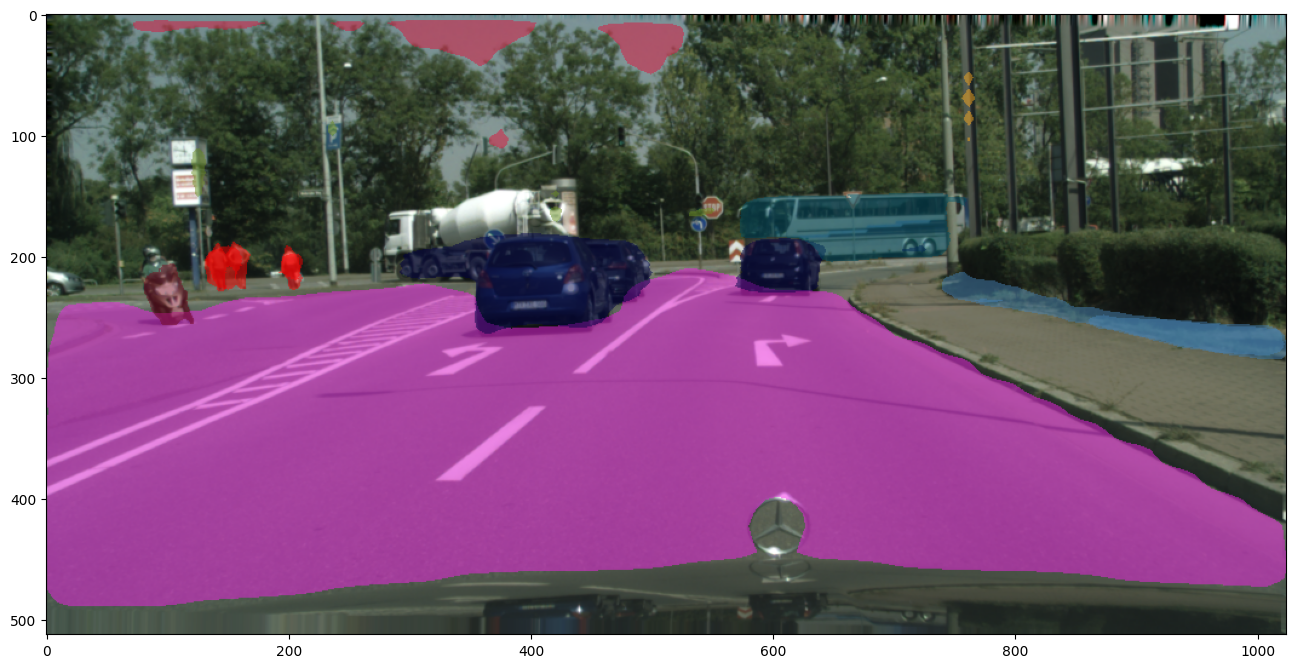

<Figure size 640x480 with 0 Axes>

In [71]:
viz_dataset_20c = CityscapesDataset(path_cfg, id_to_trainId_map_20c, ignore_index=0, transform=val_augmentation_maskrcnn, split='val')
visualize_predictions(maskrcnn_model_20c, viz_dataset_20c, class_names_20c, colors_map, captions_20c, idx=12, device='cuda', confidence_threshold=0.5)

Visualizing sample at index: 12
7 (220, 220, 0)
3 (102, 102, 156)
5 (153, 153, 153)
4 (190, 153, 153)
5 (153, 153, 153)
2 (70, 70, 70)
1 (244, 35, 232)


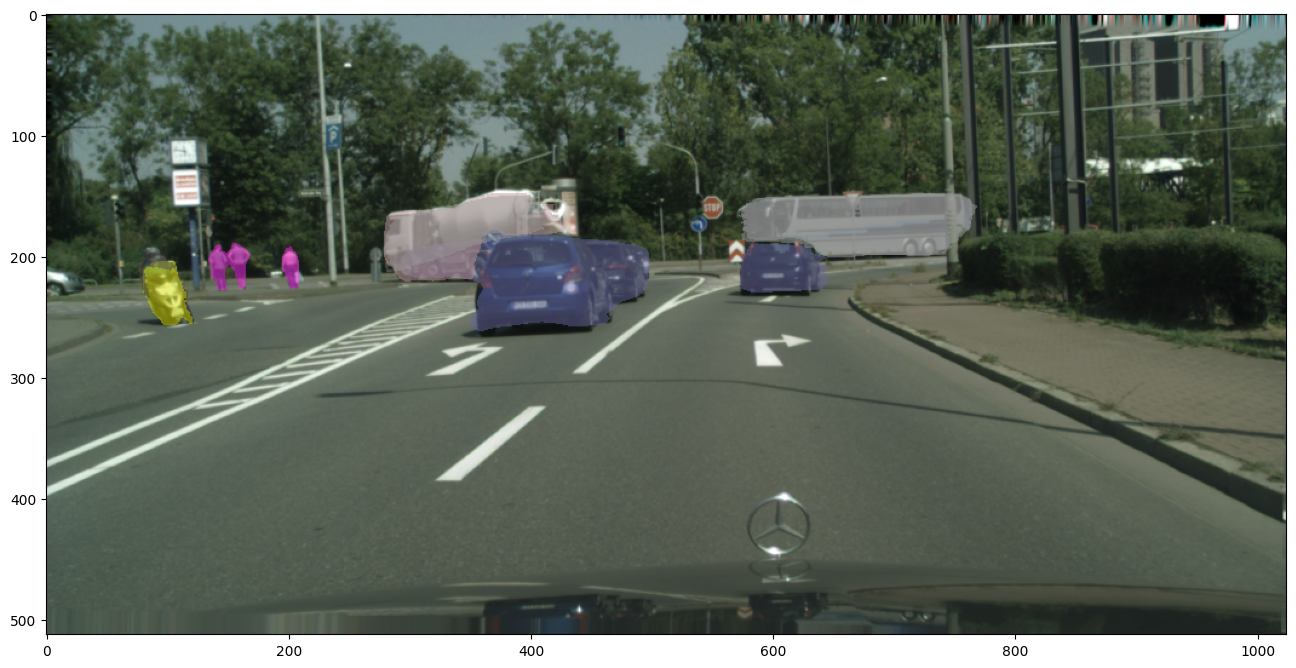

<Figure size 640x480 with 0 Axes>

In [72]:
viz_dataset_9c = CityscapesDataset(path_cfg, id_to_trainId_map_9c, ignore_index=0, transform=val_augmentation_maskrcnn, split='val')
visualize_predictions(maskrcnn_model_9c, viz_dataset_9c, class_names_9c, colors_map, captions_9c, idx=12, device='cuda', confidence_threshold=0.5)

# Load UNet

In [74]:
model_cfg.model_name = 'UNet'
unet_model_19c = build_model(model_cfg, 3, 19)
weights_dict_19c = torch.load("/kaggle/input/segmentation_cityscapes/pytorch/v01/9/UNet_dice_focal_3epoch_19c.pth", map_location=config.device)
unet_model_19c.load_state_dict(weights_dict_19c["model_state_dict"])
unet_model_19c.to(config.device)
print("Load unet complete!")



model_cfg.model_name = 'UNet'
unet_model_19c_nofocal = build_model(model_cfg, 3, 19)
weights_dict_19c_nofocal = torch.load("/kaggle/input/segmentation_cityscapes/pytorch/v01/9/UNet_dice_3epoch_19c.pth", map_location=config.device)
unet_model_19c_nofocal.load_state_dict(weights_dict_19c_nofocal["model_state_dict"])
unet_model_19c_nofocal.to(config.device)
print("Load unet complete!")



model_cfg.model_name = 'UNet'
unet_model_8c = build_model(model_cfg, 3, 8)
weights_dict_8c = torch.load("/kaggle/input/segmentation_cityscapes/pytorch/v01/9/UNet_dice_focal_3epoch_8c.pth", map_location=config.device)
unet_model_8c.load_state_dict(weights_dict_8c["model_state_dict"])
unet_model_8c.to(config.device)
print("Load unet complete!")

Load unet complete!
Load unet complete!
Load unet complete!


# Validation UNet

In [28]:
def evaluate_unet_model(model, dataloader, device, num_classes, mIoU_metric):
    """
    Correctly evaluates a U-Net model using MeanIoU, ignoring the class index 255.
    """
    print('Evaluating U-Net model with MeanIoU...')
    model.eval()

    cnt = 0
    mAP = 0.0
    mAP50 = 0.0
    no_lbl_8c = 0
    with torch.no_grad():
        with tqdm(desc="Evaluating U-Net", total=len(dataloader), leave=False) as pbar:
            for images, targets in dataloader:
                # Dataloader should stack images. If not, this line handles it.
                images = torch.stack(images).to(config.device) # [B, 3, H, W]
                cnt += len(images)     
                # instance_masks = torch.stack([t["masks"] for t in targets]).long() # [B, ?, H, W]
                semantic_masks = [convert_instance_to_semantic(t['masks'], t['labels']) for t in targets]
                semantic_masks = torch.stack(semantic_masks).squeeze(1) # [B, H, W]

                predicted_masks = model(images) # [B, 19, H, W]
                onehot_masks = torch.zeros((semantic_masks.shape[0], num_classes, semantic_masks.shape[1], semantic_masks.shape[2]), dtype=torch.long)
                for i in range(semantic_masks.shape[0]):
                    if targets[i]['labels'].shape[0] == 1:
                        continue
                    unique_classes_in_this_mask = torch.unique(semantic_masks[i])
                    for class_id in range(num_classes):
                        if class_id in unique_classes_in_this_mask:
                            onehot_masks[i, class_id, :, :] = (semantic_masks[i] == class_id).long()


                # ---------------------------------------------- mIoU 
                mIoU_metric.update(predicted_masks.long().cpu(), onehot_masks.long().cpu())
                # ---------------------------------------------- mAP
                pred_boxes = np.zeros((num_classes, 4)) # dummy mAP doesnt process what inside
                pred_scores = np.full(num_classes, 1.0) # assume model is sure about the mask
                pred_labels = np.arange(num_classes)
                for i in range(len(predicted_masks)):
                    if targets[i]['labels'].shape[0] == 1:
                        print(targets[i]['labels'])
                        no_lbl_8c += 1
                        continue
                    target_mask = targets[i]['masks'][:-1, ...].to('cpu').permute(1, 2, 0)
                    target_mask = np.array(target_mask).astype(bool)
                    
                    targets[i] = {k: np.array(v[:-1, ...].to('cpu')) for k, v in targets[i].items()}
                    # print(targets[i]['labels'], targets[i]['labels'].shape)
                    # print(pred_labels)

                    pred_masks = (predicted_masks[i] > 0.5).to('cpu').permute(1, 2, 0)
                    pred_masks = np.array(pred_masks)
                    mAP50 += compute_ap_range(targets[i]['boxes'], targets[i]['labels'], target_mask,
                                        pred_boxes, pred_labels, pred_scores, pred_masks,
                                        iou_thresholds=[0.5], verbose=0)
                    
                    mAP += compute_ap_range(targets[i]['boxes'], targets[i]['labels'], target_mask,
                                        pred_boxes, pred_labels, pred_scores, pred_masks,
                                        iou_thresholds=None, verbose=0)
                    
                pbar.update(1)
                pbar.set_postfix(iou=f"{mIoU_metric.compute():.4f}", mAP50=f"{mAP50/(cnt - no_lbl_8c):.4f}", mAP=f"{mAP/(cnt - no_lbl_8c):.4f}")
                # break

    # 6. Compute the final mIoU score
    val_miou = mIoU_metric.compute()
    mAP50 /= (cnt - no_lbl_8c)
    mAP /= (cnt - no_lbl_8c)
    # dl /= cnt
    model.train()
    return val_miou, mAP50, mAP

In [29]:
val_dataset = CityscapesDataset(path_cfg, id_to_trainId_map_19c, ignore_index=255, transform=val_augmentation_unet, split='val')
config['per_gpu_eval_batch_size'] = 4
val_dataloader = get_dataloader(val_dataset, config, is_train=False)

UNet_19c_val_miou, UNet_19c_val_mAP50, UNet_19c_val_mAP = evaluate_unet_model(unet_model_19c, val_dataloader, config.device, 19, mIoU_metric_U19c)
print(UNet_19c_val_miou)
print(UNet_19c_val_mAP50, UNet_19c_val_mAP)

Evaluating U-Net model with MeanIoU...


0.22106413543224335
0.05079857791894987 0.018813643573295947


In [36]:
val_dataset = CityscapesDataset(path_cfg, id_to_trainId_map_19c, ignore_index=255, transform=val_augmentation_unet, split='val')
config['per_gpu_eval_batch_size'] = 4
val_dataloader = get_dataloader(val_dataset, config, is_train=False)

UNet_19c_nofocal_val_miou, UNet_19c_nofocal_val_mAP50, UNet_19c_nofocal_val_mAP = evaluate_unet_model(unet_model_19c_nofocal, val_dataloader, config.device, 19, mIoU_metric_U19c)
print(UNet_19c_nofocal_val_miou)
print(UNet_19c_nofocal_val_mAP50, UNet_19c_nofocal_val_mAP)

Evaluating U-Net model with MeanIoU...


0.21937453746795654
0.047081970746194475 0.016305003726692496


In [30]:
val_dataset = CityscapesDataset(path_cfg, id_to_trainId_map_8c, ignore_index=255, transform=val_augmentation_unet, split='val')
config['per_gpu_eval_batch_size'] = 4
val_dataloader = get_dataloader(val_dataset, config, is_train=False)

UNet_8c_val_miou, UNet_8c_val_mAP50, UNet_8c_val_mAP = evaluate_unet_model(unet_model_8c, val_dataloader, config.device, 8, mIoU_metric_U8c)
print(UNet_8c_val_miou)
print(UNet_8c_val_mAP50, UNet_8c_val_mAP)

Evaluating U-Net model with MeanIoU...


Evaluating U-Net:  11%|█         | 14/125 [00:40<04:34,  2.47s/it, iou=0.0751, mAP=0.0017, mAP50=0.0078]

tensor([0])


Evaluating U-Net:  36%|███▌      | 45/125 [01:54<03:01,  2.27s/it, iou=0.0788, mAP=0.0021, mAP50=0.0127]

tensor([0])


...

Evaluating U-Net:  62%|██████▏   | 77/125 [03:08<01:42,  2.15s/it, iou=0.0779, mAP=0.0020, mAP50=0.0108]

tensor([0])


Evaluating U-Net:  62%|██████▏   | 78/125 [03:10<01:41,  2.16s/it, iou=0.0778, mAP=0.0020, mAP50=0.0106]

tensor([0])


0.08207789808511734
0.007304421827501181 0.0014034864047960355


# Visualize UNet

In [30]:
def visualize_unet(unet_model, dataset, class_id_to_name, class_id_to_color, idx=None):
    """
    Loads a sample, runs inference, and displays the original image,
    ground truth mask, and predicted mask side-by-side.
    """
    
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)
    original_image_viz = T.Resize((512, 1024))(read_image(dataset.images[idx]))
    unet_model.eval()

    with torch.no_grad():
        # 1. Get data from the dataset
        image_tensor, target_dict = dataset[idx]
        
        # Get the instance masks and labels from the target dictionary
        gt_instance_masks = target_dict['masks']   # Shape: [N_instances, H, W]
        gt_instance_labels = target_dict['labels'] # Shape: [N_instances]
        
        # Convert the instance ground truth to a single semantic mask
        gt_semantic_mask = convert_instance_to_semantic(gt_instance_masks, gt_instance_labels)
    
        # 2. Prepare image for the model and run inference
        input_tensor = image_tensor.unsqueeze(0).to(config.device)
        logits = unet_model(input_tensor)
        
        # 3. Process the prediction: Use argmax (this part was already correct)
        pred_semantic_mask = torch.argmax(logits.squeeze(0), dim=0).cpu()
    
    # Colorize the ground truth and prediction masks
    gt_color_mask = colorize_mask(gt_semantic_mask, class_id_to_color)
    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color)
    
    # 5. Display the results
    plt.figure(figsize=(24, 8))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_viz.permute(1, 2, 0))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_color_mask.permute(1, 2, 0))
    plt.title("Ground Truth")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_color_mask.permute(1, 2, 0))
    plt.title("U-Net Prediction")
    plt.axis('off')
    
    import matplotlib.patches as mpatches
    legend_patches = []
    # Sort by ID for a consistent legend order
    for class_id in sorted(class_id_to_name.keys()):
        if class_id != 0: # Don't include the ignore label in the legend
            name = class_id_to_name[class_id]
            color = np.array(class_id_to_color[class_id]) / 255.0 # Matplotlib expects colors in [0, 1] range
            patch = mpatches.Patch(color=color, label=f"{class_id}: {name}")
            legend_patches.append(patch)
    
    # Add legend to the side of the plots
    plt.legend(handles=legend_patches, bbox_to_anchor=(1.0, 0.9), loc='upper left')
    plt.show()
    unet_model.train()

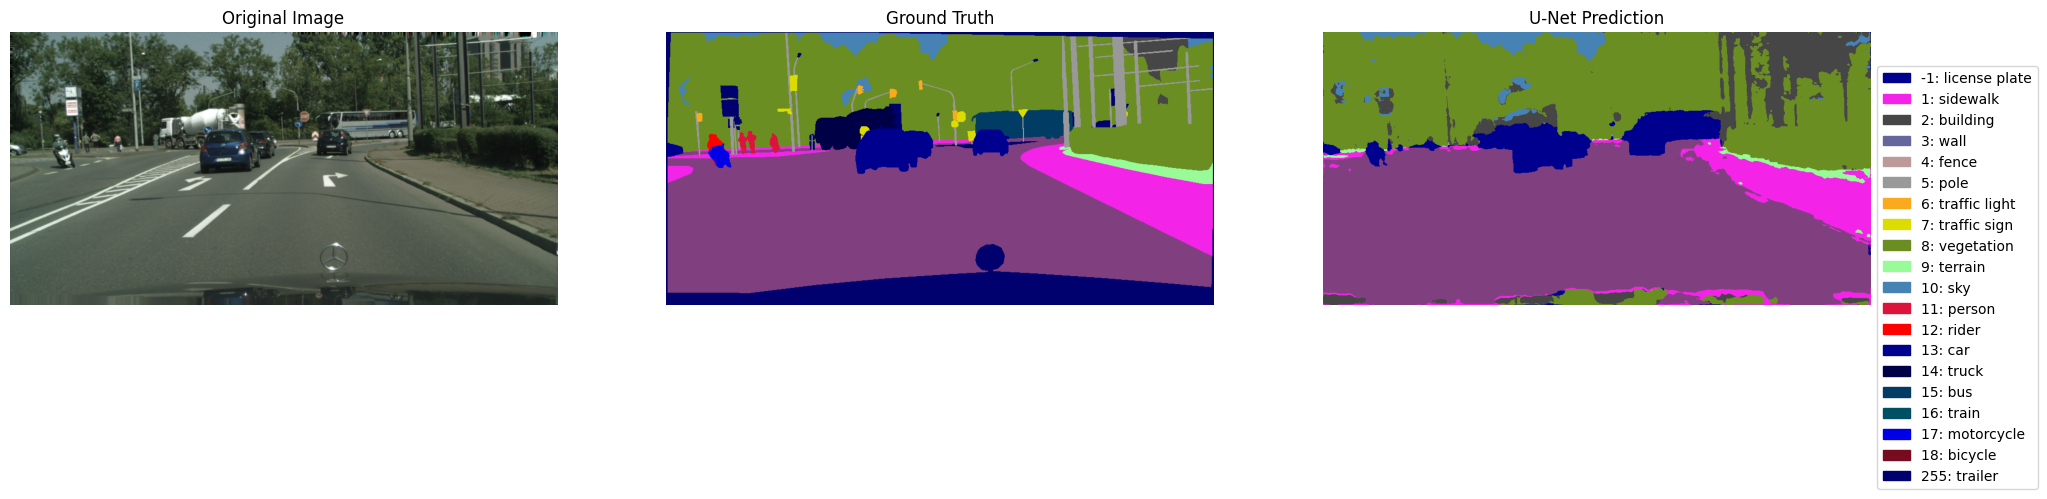

In [31]:
test_dataset_for_viz = CityscapesDataset(path_cfg, id_to_trainId_map_19c, ignore_index=255, transform=val_augmentation_maskrcnn, split='val')
visualize_unet(unet_model_19c, test_dataset_for_viz, class_id_to_name_19c, class_id_to_color_19c, idx=12)

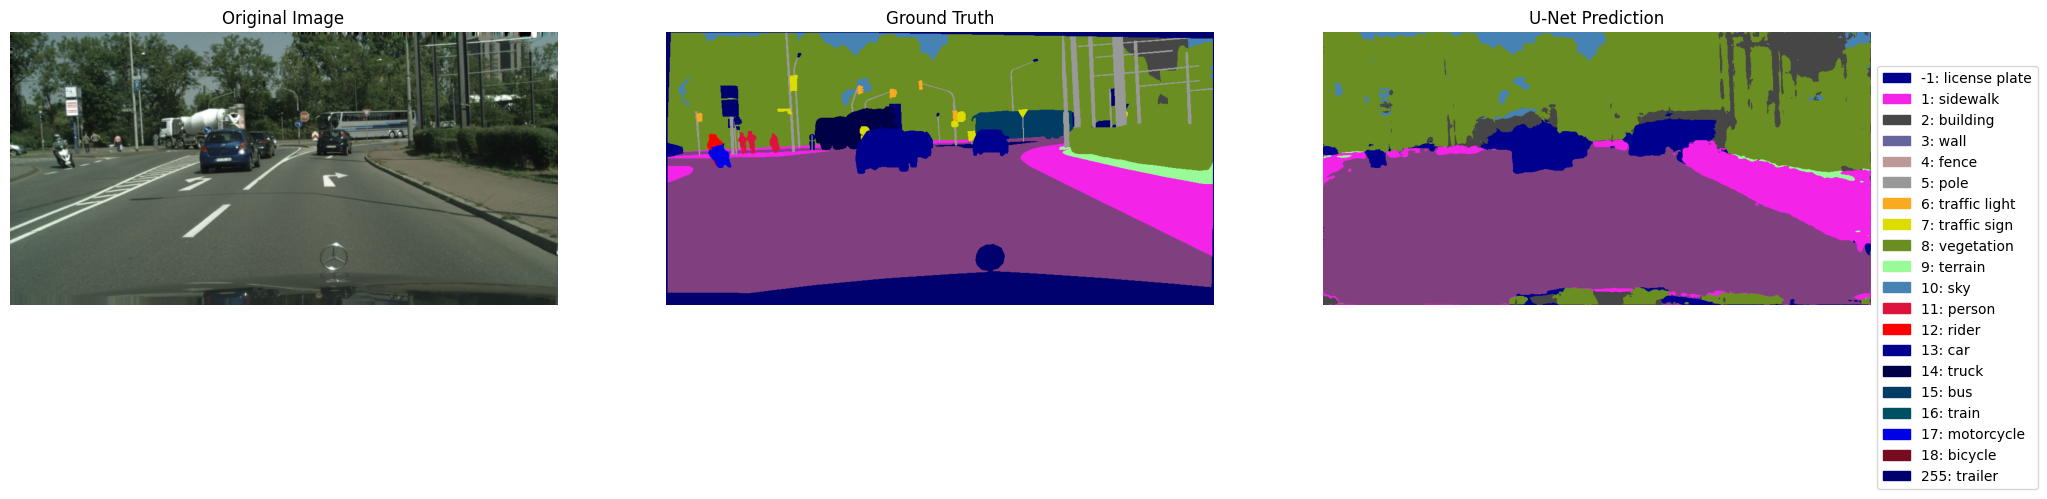

In [32]:
test_dataset_for_viz = CityscapesDataset(path_cfg, id_to_trainId_map_19c, ignore_index=255, transform=val_augmentation_maskrcnn, split='val')
visualize_unet(unet_model_19c_nofocal, test_dataset_for_viz, class_id_to_name_19c, class_id_to_color_19c, idx=12)

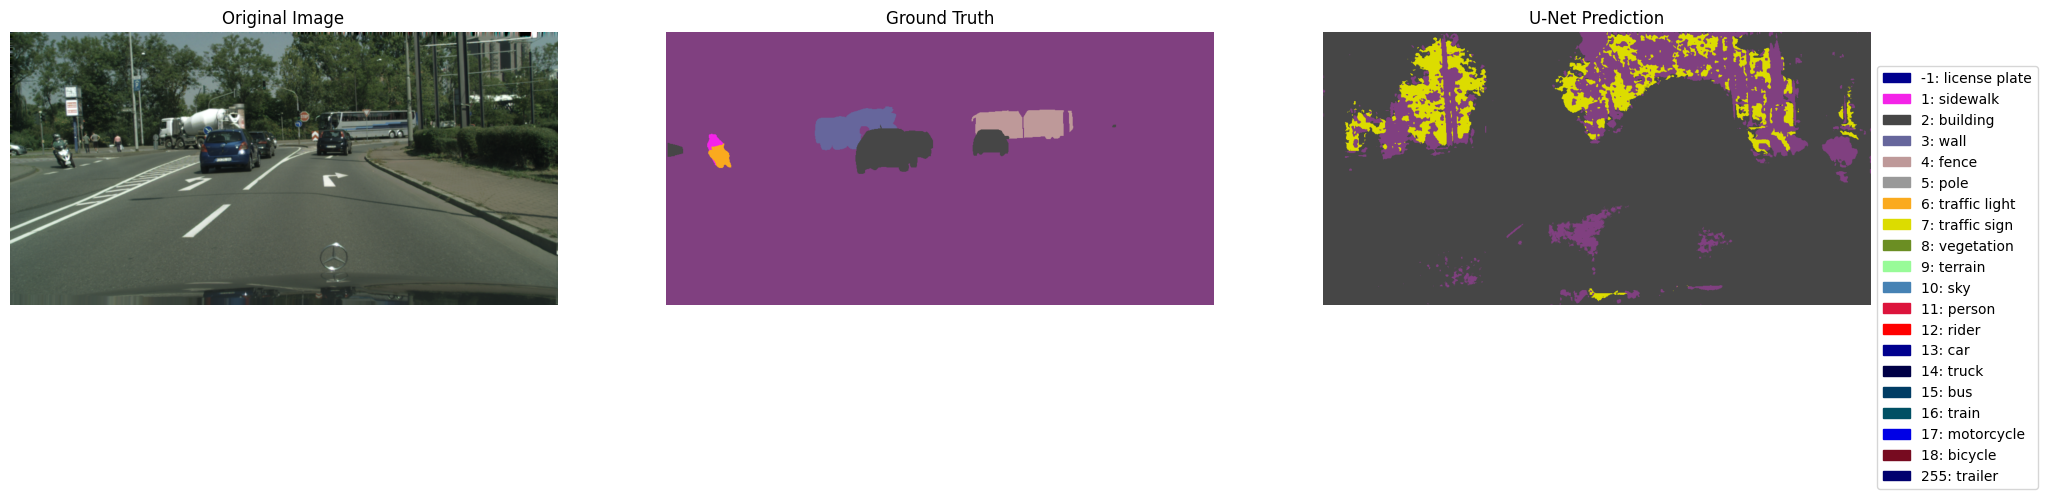

In [33]:
test_dataset_for_viz = CityscapesDataset(path_cfg, id_to_trainId_map_8c, ignore_index=255, transform=val_augmentation_maskrcnn, split='val')
visualize_unet(unet_model_8c, test_dataset_for_viz, class_id_to_name_8c, class_id_to_color_8c, idx=12)

# Both Visualize compare to GT

In [44]:
viz_dataset_20c = CityscapesDataset(path_cfg, id_to_trainId_map_20c, ignore_index=0, transform=val_augmentation_maskrcnn, split='val')
viz_dataset_19c = CityscapesDataset(path_cfg, id_to_trainId_map_19c, ignore_index=255, transform=val_augmentation_unet, split='val')
viz_dataset_9c = CityscapesDataset(path_cfg, id_to_trainId_map_9c, ignore_index=0, transform=val_augmentation_maskrcnn, split='val')
viz_dataset_8c = CityscapesDataset(path_cfg, id_to_trainId_map_8c, ignore_index=255, transform=val_augmentation_unet, split='val')

## FULL

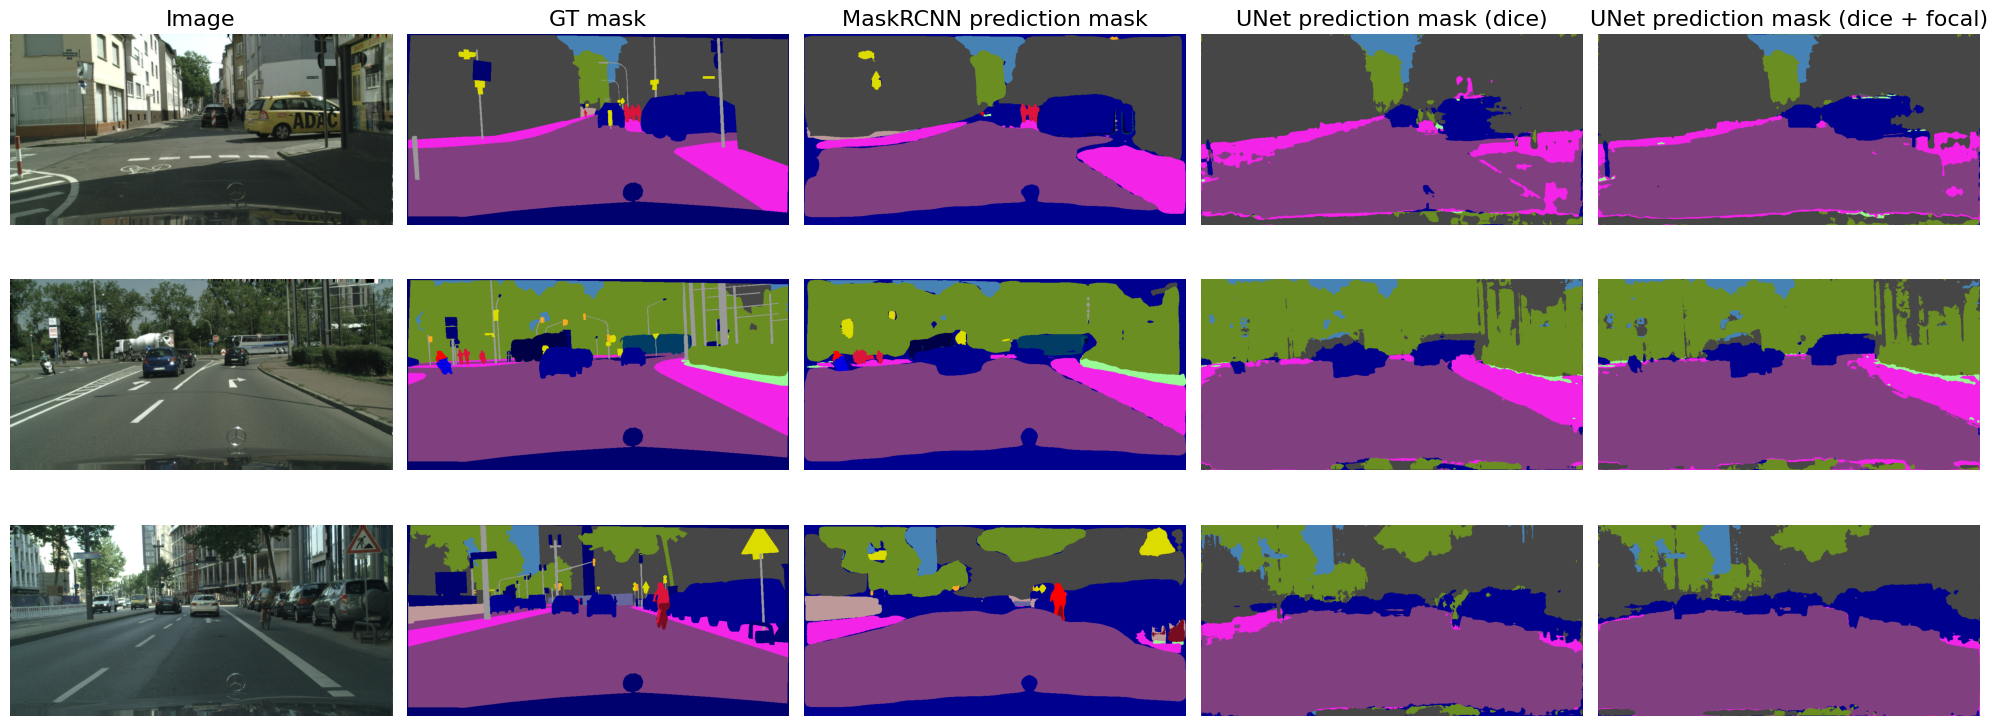

In [116]:
idx_list = [0, 12, 36]

plt.figure(figsize=(20, 8))
for viz_idx in range(len(idx_list)):
    idx = idx_list[viz_idx]
    ##############################################################
    plt.subplot(len(idx_list), 5, viz_idx*5+1) 
    if viz_idx == 0:
        plt.title("Image", fontsize=16)
    original_image = T.Resize((512, 1024))(read_image(viz_dataset_20c.images[idx])).permute(1, 2, 0)
    original_image = np.array(original_image)
    plt.axis('off')
    plt.imshow(original_image)
    
    ##############################################################
    plt.subplot(len(idx_list), 5, viz_idx*5+2)
    if viz_idx == 0:
        plt.title("GT mask", fontsize=16)
    _, target = viz_dataset_19c[idx]
    gt_mask = target['masks']
    gt_labels = target['labels']
    gt_mask = convert_instance_to_semantic(gt_mask, gt_labels)
    gt_mask = colorize_mask(gt_mask, class_id_to_color_19c)
    plt.axis('off')
    plt.imshow(gt_mask.permute(1, 2, 0))
    
    
    ##############################################################
    plt.subplot(len(idx_list), 5, viz_idx*5+3)
    if viz_idx == 0:
        plt.title("MaskRCNN prediction mask", fontsize=16)
    maskrcnn_model_20c.eval()
    with torch.no_grad():
        img, t = viz_dataset_20c[idx]
        img = img.unsqueeze(0).to(config.device)
        pred_dict = maskrcnn_model_20c(img)
        

        pred_semantic_mask = torch.full(
            (img.shape[2], img.shape[3]),
            fill_value=0, 
            dtype=torch.long,
            device=config.device
        )
        
        # pred_scores = pred_dict[0]['scores'].cpu().numpy()
        # high_conf_indices = np.where(pred_scores >= 0.5)[0]
        # pred_mask = pred_dict[0]['masks'][high_conf_indices].squeeze(1).cpu()
        # pred_labels = pred_dict[0]['labels'][high_conf_indices].cpu()
        pred_scores = pred_dict[0]['scores'].cpu()
        pred_mask = pred_dict[0]['masks'].squeeze(1).cpu()
        pred_labels = pred_dict[0]['labels'].cpu()

        if pred_mask.numel() > 0:
            # Squeeze the channel dimension: [N_pred, H_img, W_img]

            # Sort predictions by score in ascending order
            sorted_indices = torch.argsort(pred_scores, descending=False)
            pred_mask = pred_mask[sorted_indices]
            pred_labels = pred_labels[sorted_indices]

            for j in range(pred_mask.shape[0]):
                mask_j = (pred_mask[j] > 0.5)
                label_j = pred_labels[j]

                if label_j < 20:
                    pred_semantic_mask[mask_j] = label_j # gradually replaced by class with higher score
        # pred_boxes = pred_dict['boxes'][high_conf_indices].cpu().numpy()
    
    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color_20c)
    plt.axis('off')
    plt.imshow(pred_color_mask.permute(1, 2, 0))
        
        
    
    ##############################################################
    plt.subplot(len(idx_list), 5, viz_idx*5+4)
    if viz_idx == 0:
        plt.title("UNet prediction mask (dice)", fontsize=16)
    unet_model_19c_nofocal.eval()
    with torch.no_grad():
        img, t = viz_dataset_19c[idx]
        img = img.unsqueeze(0).to(config.device)
        pred_logits = unet_model_19c_nofocal(img)
        pred_semantic_mask = torch.argmax(pred_logits.squeeze(0), dim=0).cpu()

    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color_19c)
    plt.axis('off')
    plt.imshow(pred_color_mask.permute(1, 2, 0))
    
    
    ##############################################################
    plt.subplot(len(idx_list), 5, viz_idx*5+5)
    if viz_idx == 0:
        plt.title("UNet prediction mask (dice + focal)", fontsize=16)
    unet_model_19c.eval()
    with torch.no_grad():
        img, t = viz_dataset_19c[idx]
        img = img.unsqueeze(0).to(config.device)
        pred_logits = unet_model_19c(img)
        pred_semantic_mask = torch.argmax(pred_logits.squeeze(0), dim=0).cpu()
    
    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color_19c)
    plt.axis('off')
    plt.imshow(pred_color_mask.permute(1, 2, 0))

plt.tight_layout()
plt.savefig('/kaggle/working/CompareFull.png')
plt.savefig('/kaggle/working/CompareFull_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## OBJ only

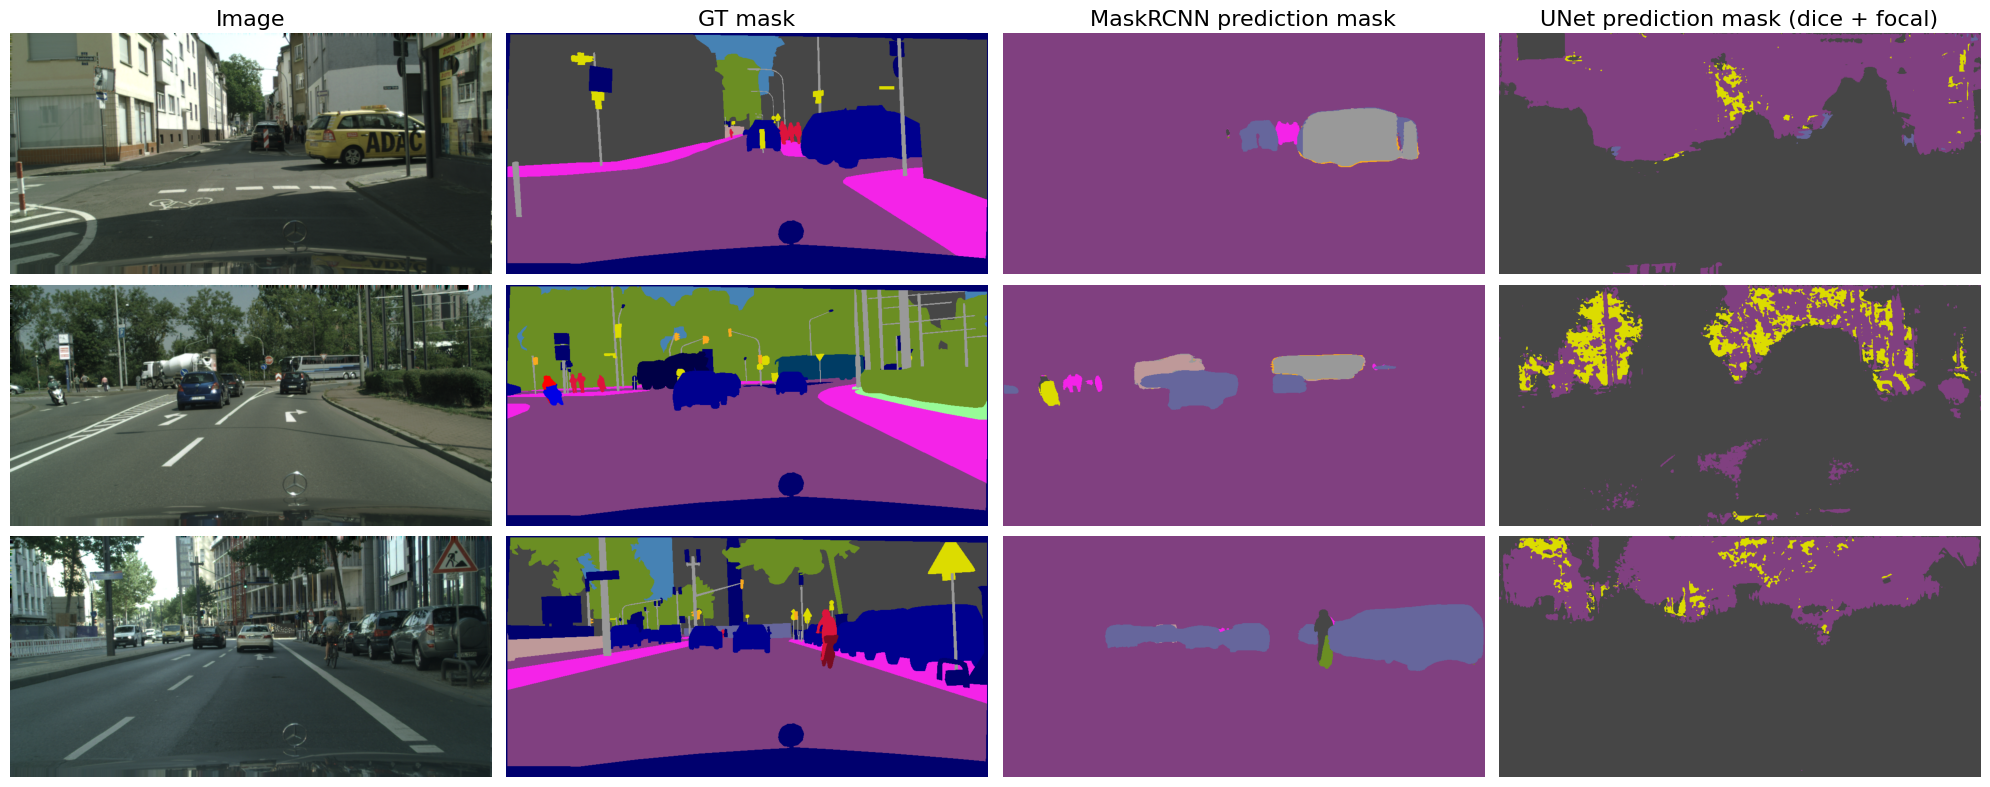

In [117]:
idx_list = [0, 12, 36]

plt.figure(figsize=(20, 8))
for viz_idx in range(len(idx_list)):
    idx = idx_list[viz_idx]
    ##############################################################
    plt.subplot(len(idx_list), 4, viz_idx*4+1) 
    if viz_idx == 0:
        plt.title("Image", fontsize=16)
    original_image = T.Resize((512, 1024))(read_image(viz_dataset_9c.images[idx])).permute(1, 2, 0)
    original_image = np.array(original_image)
    plt.axis('off')
    plt.imshow(original_image)
    
    ##############################################################
    plt.subplot(len(idx_list), 4, viz_idx*4+2)
    if viz_idx == 0:
        plt.title("GT mask", fontsize=16)
    _, target = viz_dataset_19c[idx]
    gt_mask = target['masks']
    gt_labels = target['labels']
    gt_mask = convert_instance_to_semantic(gt_mask, gt_labels)
    gt_mask = colorize_mask(gt_mask, class_id_to_color_19c)
    plt.axis('off')
    plt.imshow(gt_mask.permute(1, 2, 0))
    
    
    ##############################################################
    plt.subplot(len(idx_list), 4, viz_idx*4+3)
    if viz_idx == 0:
        plt.title("MaskRCNN prediction mask", fontsize=16)
    maskrcnn_model_9c.eval()
    with torch.no_grad():
        img, t = viz_dataset_9c[idx]
        img = img.unsqueeze(0).to(config.device)
        pred_dict = maskrcnn_model_9c(img)
        

        pred_semantic_mask = torch.full(
            (img.shape[2], img.shape[3]),
            fill_value=0, 
            dtype=torch.long,
            device=config.device
        )
        
        # pred_scores = pred_dict[0]['scores'].cpu().numpy()
        # high_conf_indices = np.where(pred_scores >= 0.5)[0]
        # pred_mask = pred_dict[0]['masks'][high_conf_indices].squeeze(1).cpu()
        # pred_labels = pred_dict[0]['labels'][high_conf_indices].cpu()
        pred_scores = pred_dict[0]['scores'].cpu()
        pred_mask = pred_dict[0]['masks'].squeeze(1).cpu()
        pred_labels = pred_dict[0]['labels'].cpu()

        if pred_mask.numel() > 0:
            # Squeeze the channel dimension: [N_pred, H_img, W_img]

            # Sort predictions by score in ascending order
            sorted_indices = torch.argsort(pred_scores, descending=False)
            pred_mask = pred_mask[sorted_indices]
            pred_labels = pred_labels[sorted_indices]

            for j in range(pred_mask.shape[0]):
                mask_j = (pred_mask[j] > 0.5)
                label_j = pred_labels[j]

                if label_j < 20:
                    pred_semantic_mask[mask_j] = label_j # gradually replaced by class with higher score
        # pred_boxes = pred_dict['boxes'][high_conf_indices].cpu().numpy()
    
    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color_9c)
    plt.axis('off')
    plt.imshow(pred_color_mask.permute(1, 2, 0))
        
        
    
    ##############################################################
    plt.subplot(len(idx_list), 4, viz_idx*4+4)
    if viz_idx == 0:
        plt.title("UNet prediction mask (dice + focal)", fontsize=16)
    unet_model_8c.eval()
    with torch.no_grad():
        img, t = viz_dataset_8c[idx]
        img = img.unsqueeze(0).to(config.device)
        pred_logits = unet_model_8c(img)
        pred_semantic_mask = torch.argmax(pred_logits.squeeze(0), dim=0).cpu()

    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color_8c)
    plt.axis('off')
    plt.imshow(pred_color_mask.permute(1, 2, 0))
    

plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/CompareObject.png')
plt.savefig('/kaggle/working/CompareObject_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Vis video

In [98]:

# Original: https://github.com/matterport/Mask_RCNN
def apply_mask(image, mask, color, alpha=0.7):
    """Apply the given mask to the image.
    """
    for c in range(3):
        image[:, :, c] = np.where(mask == 1,
                                  image[:, :, c] *
                                  (1 - alpha) + alpha * color[c],
                                  image[:, :, c])
    return image
    
# Original: https://github.com/matterport/Mask_RCNN
def display_instances(image, boxes, masks, class_ids, class_names,
                      scores=None, title="",
                      figsize=(16, 16), ax=None,
                      show_mask=True, show_bbox=False,
                      colors=None, captions=None):
    """
    boxes: [num_instance, (y1, x1, y2, x2, class_id)] in image coordinates.
    masks: [height, width, num_instances]
    class_ids: [num_instances]
    class_names: list of class names of the dataset
    scores: (optional) confidence scores for each box
    title: (optional) Figure title
    show_mask, show_bbox: To show masks and bounding boxes or not
    figsize: (optional) the size of the image
    colors: (optional) An array or colors to use with each object
    captions: (optional) A list of strings to use as captions for each object
    """
    # Number of instances
    N = boxes.shape[0]
    if not N:
        print("\n*** No instances to display *** \n")
    else:
        assert boxes.shape[0] == masks.shape[-1] == class_ids.shape[0]

    # If no axis is passed, create one and automatically call show()
    auto_show = False
    # if not ax:
    #     _, ax = plt.subplots(1, figsize=figsize)
    #     auto_show = True

    # Generate random colors if not
    colors = colors or random_colors(N)

    # Show area outside image boundaries.
    height, width = image.shape[:2]

    masked_image = image.astype(np.uint32).copy()
    for i in range(N):
        color = colors[class_ids[i]]

        # # Bounding box
        # if not np.any(boxes[i]):
        #     # Skip this instance. Has no bbox. Likely lost in image cropping.
        #     continue
        # y1, x1, y2, x2 = boxes[i]
        # if show_bbox:
        #     p = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
        #                         alpha=0.7, linestyle="dashed",
        #                         edgecolor=color, facecolor='none')
        #     ax.add_patch(p)

        # # Label
        # if not captions:
        #     class_id = class_ids[i]
        #     score = scores[i] if scores is not None else None
        #     label = class_names[class_id]
        #     caption = "{} {:.3f}".format(label, score) if score else label
        # else:
        #     caption = captions[i]
        # ax.text(x1, y1 + 8, caption,
        #         color='w', size=11, backgroundcolor="none")

        # Mask
        mask = masks[:, :, i]
        if show_mask:
            masked_image = apply_mask(masked_image, mask, color)

        # Mask Polygon
        # Pad to ensure proper polygons for masks that touch image edges.
        # padded_mask = np.zeros(
        #     (mask.shape[0] + 2, mask.shape[1] + 2), dtype=np.uint8)
        # padded_mask[1:-1, 1:-1] = mask
        # contours = find_contours(padded_mask, 0.5)
        # for verts in contours:
        #     # Subtract the padding and flip (y, x) to (x, y)
        #     verts = np.fliplr(verts) - 1
        #     p = Polygon(verts, facecolor="none", edgecolor=color)
        #     ax.add_patch(p)
    # ax.imshow(masked_image.astype(np.uint8))
    return masked_image.astype(np.uint8)

In [104]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from natsort import natsorted

def process_image(image, maskrcnn_model, transform, device):
    """
    Applies the Mask R-CNN model to a single image and returns the visualized output.
    """
    img_tensor = transform(image).unsqueeze(0).to(device)
    maskrcnn_model.eval()
    with torch.no_grad():
        pred_dict = maskrcnn_model(img_tensor)

        pred_semantic_mask = torch.full(
            (img_tensor.shape[2], img_tensor.shape[3]),
            fill_value=0,
            dtype=torch.long,
            device=device
        )

        pred_scores = pred_dict[0]['scores'].cpu()
        pred_mask = pred_dict[0]['masks'].squeeze(1).cpu()
        pred_labels = pred_dict[0]['labels'].cpu()

        if pred_mask.numel() > 0:
            # Sort predictions by score in ascending order
            sorted_indices = torch.argsort(pred_scores, descending=False)
            pred_mask = pred_mask[sorted_indices]
            pred_labels = pred_labels[sorted_indices]

            for j in range(pred_mask.shape[0]):
                mask_j = (pred_mask[j] > 0.5)
                label_j = pred_labels[j]

                if label_j < 20:
                    pred_semantic_mask[mask_j] = label_j

    pred_color_mask = colorize_mask(pred_semantic_mask.cpu(), class_id_to_color_9c)
    
    output_image = pred_color_mask.permute(1, 2, 0).numpy()
    
    # Convert from RGB (matplotlib) to BGR (OpenCV)
    output_image = cv2.cvtColor(output_image.astype(np.uint8), cv2.COLOR_RGB2BGR)

    return output_image





def process_image_2(image, maskrcnn_model, transform, device):
    """
    Applies the Mask R-CNN model to a single image and returns the visualized output.
    """
    img_tensor = transform(image).unsqueeze(0).to(device)
    maskrcnn_model.eval()
    with torch.no_grad():
        pred_dict = maskrcnn_model(img_tensor)[0]

        pred_scores = pred_dict['scores'].cpu().numpy()
        high_conf_indices = np.where(pred_scores >= 0.5)[0]
    
        # Filter predictions based on the confidence threshold
        pred_masks = (pred_dict['masks'][high_conf_indices] > 0.5).squeeze(1).permute(1, 2, 0).cpu().numpy()
        pred_labels = pred_dict['labels'][high_conf_indices].cpu().numpy()
        pred_boxes = pred_dict['boxes'][high_conf_indices].cpu().numpy()

    img_np = T.Resize((512, 1024))(image).permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    pred_labels = (lambda x: x-1)(pred_labels) # from 1-indexed to 0-indexed
    # print(pred_labels)
    pred_color_mask = display_instances(img_np, pred_boxes, pred_masks, pred_labels, class_names_20c, show_bbox=False, colors=colors_map, captions=captions_20c)
    
    output_image = pred_color_mask
    
    # Convert from RGB (matplotlib) to BGR (OpenCV)
    output_image = cv2.cvtColor(output_image.astype(np.uint8), cv2.COLOR_RGB2BGR)

    return output_image

def create_video_from_folder(image_folder, output_video_path, output_video_path_2, model, transform, device, fps=30.0):
    """
    Reads images from a folder, applies the model, and creates a video from the output.
    """
    # Get a sorted list of image file paths from the folder.
    image_files = natsorted([os.path.join(image_folder, f) for f in os.listdir(image_folder)
                           if f.endswith(('.png', '.jpg', '.jpeg'))])

    if not image_files:
        print(f"No images found in the directory: {image_folder}")
        return

    # Read the first image to get the frame dimensions.
    first_frame = cv2.imread(image_files[0])
    if first_frame is None:
        print(f"Error reading the first image: {image_files[0]}")
        return
        
    height, width, layers = first_frame.shape
    # Define the codec and create VideoWriter object.
    fourcc = cv2.VideoWriter_fourcc(*"mp4v") # Or use 'XVID', 'MJPG', etc.
    out = cv2.VideoWriter(output_video_path, fourcc, float(fps), (1024, 512))
    fourcc_2 = cv2.VideoWriter_fourcc(*"mp4v") # Or use 'XVID', 'MJPG', etc.
    out_2 = cv2.VideoWriter(output_video_path_2, fourcc_2, float(fps), (1024, 512))

    for image_file in tqdm(image_files):
        # print(f"Processing image {i+1}/{len(image_files)}: {os.path.basename(image_file)}")
        image = read_image(image_file)
        processed_frame = process_image(image, model, transform, device)
        processed_frame_2 = process_image_2(image, model, transform, device)
        out.write(processed_frame)
        out_2.write(processed_frame_2)

    # Release everything when the job is finished
    # cv2.destroyAllWindows()
    out.release()
    out_2.release()
    print(f"Finished processing. Output video saved to {output_video_path}")

In [105]:
image_folder = "/kaggle/input/cityscapes/demoVideo/demoVideo/stuttgart_00"
output_video = '/kaggle/working/test_video_semantic.mp4'
output_video_2 = '/kaggle/working/test_video_color.mp4'

create_video_from_folder(image_folder, output_video, output_video_2, maskrcnn_model_20c, val_augmentation_maskrcnn, config.device, fps=24.0)

100%|██████████| 599/599 [10:12<00:00,  1.02s/it]

Finished processing. Output video saved to /kaggle/working/test_video_semantic.mp4


# Check confidence in each class

In [115]:
def pred_probs_hist(model, viz_dataset, device, idx=None):
    if not idx:
        idx = np.random.randint(len(viz_dataset))
    img, _ = viz_dataset[idx]
    with torch.no_grad():
        images = img.unsqueeze(0).to(device)
        predictions = model(images)
            
        for i in range(len(predictions)):
            pred = predictions[i]
            pred_scores = pred['scores'].cpu().numpy()
            high_conf_indices = np.where(pred_scores >= 0.7)[0]
            pred_scores = pred_scores[high_conf_indices]
            pred_masks = (pred['masks'][high_conf_indices] > 0.5).squeeze(1).cpu().numpy()
            pred_labels = pred['labels'][high_conf_indices].cpu().numpy()
            # pred_boxes = pred['boxes'][high_conf_indices].cpu().numpy()

            ind = np.argsort(pred_labels, axis=0)
            pred_labels = pred_labels[ind]
            pred_masks = pred_masks[ind, ...]
            pred_masks = np.transpose(pred_masks, (1, 2, 0))
            plt.figure(figsize=(16, 8))
            num_rows = int(len(pred_labels)/3) + 1
            for i in range(int(len(pred_labels)/3)):
                if i*3+1 <= len(pred_labels):
                    plt.subplot(num_rows, 3, i*3+1)
                    p1 = pred_masks[..., i*3].copy().astype(float)
                    plt.hist(p1.reshape(-1))
                    plt.xlabel(f"Label: {pred_labels[i*3]}")

                if i*3+2 <= len(pred_labels):
                    plt.subplot(num_rows, 3, i*3+2)
                    p1 = pred_masks[..., i*3+1].copy().astype(float)
                    plt.hist(p1.reshape(-1))
                    plt.xlabel(f"Label: {pred_labels[i*3+1]}")

                if i*3+3 <= len(pred_labels):
                    plt.subplot(num_rows, 3, i*3+3)
                    p1 = pred_masks[..., i*3+2].copy().astype(float)
                    plt.hist(p1.reshape(-1))
                    plt.xlabel(f"Label: {pred_labels[i*3+2]}")
            plt.tight_layout()
            plt.show()

[ 1 11  8 10 14  9  5  8  7 14]
[0 6 8 7 2 5 3 1 4 9]


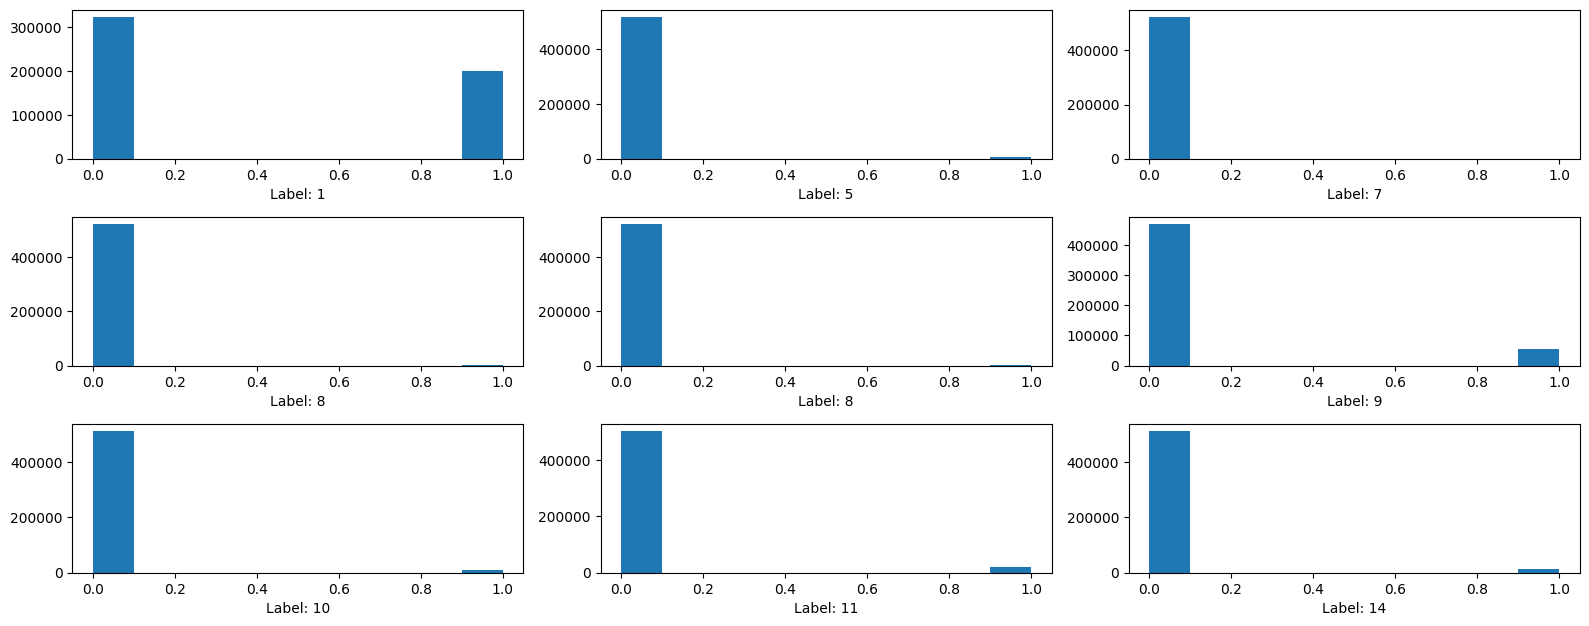

In [117]:
pred_probs_hist(maskrcnn_model_20c, viz_dataset_20c, config.device)